In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import h5py
import matplotlib.pyplot as plt
from os.path import join, exists
import os
import matplotlib as mpl
mpl.style.use('style.mcstyle')
from tqdm import tqdm
import pandas as pd

# os.chdir('/home/x-mho1/git/ltu-cmass-run')

from astropy.cosmology import Planck18 as cosmo

In [2]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'
wdir = '/work/hdd/bdne/maho3/cmass-ili'

### Test the effect of noising in data-space

In [ ]:
# Baseline
nbody = 'quijotelike'
sim = 'fastpm_4k_niall2'
tracer = 'galaxy'
postfix = 'kmin-0.0_kmax-0.4'
summlist = ['nbar', 'zPk0', 'zPk2', 'zPk4', 'zBk0']
summaries = '+'.join(summlist)
modeldir = join(wdir, nbody, sim, 'models', tracer, summaries, postfix)
print(modeldir)

nbar = np.load(join(modeldir, 'x_test.npy'))[:, -1]

In [ ]:
ids_test = np.load(join(modeldir, 'ids_test.npy')).astype(int)
ids_test = ids_test[ids_test < 2000]
ids_test = list(set(ids_test))
ids_test = ids_test[::]
len(ids_test)

In [ ]:
print(' '.join(np.array(list(set(ids_test))).astype(str)))

```for i in 514 1539 15 1557 26 28 1055 31 545 1057 37 549 39 550 551 1061 43 1573 1582 1587 1080 1592 58 570 1599 69 1610 587 76 1103 81 1617 596 1109 1622 1624 612 101 103 619 1644 1137 1139 1651 1141 121 634 1150 641 1665 645 1158 136 1162 140 653 1168 1169 1170 1174 151 1175 1686 671 1695 162 1701 1196 1197 174 1202 179 180 1203 182 1205 184 1217 196 197 708 202 1226 1236 221 733 1248 1762 232 747 1260 750 1266 245 1269 1271 250 1275 1786 1277 1284 1285 1797 266 778 781 1807 1811 789 1813 1310 1824 291 1828 807 1831 298 812 1847 1848 1850 318 1342 1855 833 1345 1861 838 327 329 841 844 1868 847 337 1362 851 340 860 349 862 351 1885 354 1378 358 872 873 1903 1394 373 886 376 1917 382 1409 899 388 1935 914 1426 1427 1944 1433 922 923 414 416 929 1441 1448 1450 1451 1965 430 943 1968 1969 1464 1976 443 444 956 1986 1479 456 459 1996 973 1999 1489 978 1493 982 472 1503 1504 483 484 995 1000 489 1001 1006 1519 1521 1010 1017; do echo $i; mkdir $i; cd $i; ln -s ../../../nbody/L1000-N128/$i/config.yaml; ln -s ../../../nbody/L1000-N128/$i/halos.h5; cd ..; done```

In [ ]:
Nrows = 20
onep_variation = np.zeros((Nrows, 2))
xrange = np.linspace(0, 4.5105, Nrows//2)
onep_variation[:Nrows//2, 0] = xrange
onep_variation[Nrows//2:, 1] = xrange

# onep_variation
# np.savetxt('/u/maho3/git/ltu-cmass/noise1p.csv', onep_variation, delimiter=',')
pd.DataFrame(onep_variation)

In [ ]:
Nrows = 49
Nsamples = int(np.sqrt(Nrows))
xrange = np.linspace(0, 4.5105, Nsamples)
grid_variation = np.array(np.meshgrid(xrange, xrange)).reshape(2, -1).T

# np.savetxt('/u/maho3/git/ltu-cmass/noisegrid.csv', grid_variation, delimiter=',')
pd.DataFrame(grid_variation)

#### Self-consistent noising

In [ ]:

a = '0.666667'


def load_Pk(filepath, kmax=0.4, z=True):
    b = 'z' if z else ''
    with h5py.File(filepath, 'r') as f:
        k = f[a][b+'Pk_k3D'][:]
        Pk = f[a][b+'Pk'][:]

    if kmax is not None:
        mask = k < kmax
        Pk = Pk[mask]
        k = k[mask]

    return k, Pk

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cmap = plt.get_cmap('viridis')
noises = np.loadtxt('/u/maho3/git/ltu-cmass/noise1p.csv', delimiter=',')
norm = mcolors.Normalize(noises.min(), noises.max())

In [ ]:
basepath = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody_1pnoise/L1000-N128'
lhid = 15


filepath = join(basepath, str(lhid), 'diag', 'galaxies',
                f'hod00001_noise{10:06}.h5')
k0, p0 = load_Pk(filepath)

f, axs = plt.subplots(1, 3, sharex=True, figsize=(13, 4))
for i in range(1, 10):
    filepath = join(basepath, str(lhid), 'diag', 'galaxies',
                    f'hod00001_noise{i:06}.h5')
    try:
        k, p = load_Pk(filepath)
    except:
        continue

    n = noises[i, 0]
    c = cmap(norm(n))

    ax = axs[0]
    ax.plot(k, p[:, 0]/p0[:, 0], c=c)

    ax = axs[1]
    ax.plot(k, (k*p[:, 1]), c=c)

    ax = axs[2]
    ax.plot(k, k*p[:, 2], c=c)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([]) # Optional, usually needed for older matplotlib versions
cbar = f.colorbar(sm, ax=axs, pad=-0.45, aspect=30)
cbar.set_label('sigma_radial')

axs[0].set_ylabel('Pk0 Noised/Pk0 Unnoised')
axs[1].axhline(0, ls='--', c='k')
axs[2].axhline(0, ls='--', c='k')
axs[1].set_ylabel('k*Pk2 Noised')
axs[2].set_ylabel('k*Pk4 Noised')
f.suptitle('sigma_transverse=0')

plt.tight_layout()

In [ ]:
basepath = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody_1pnoise/L1000-N128'
lhid = 15


filepath = join(basepath, str(lhid), 'diag', 'galaxies',
                f'hod00001_noise{10:06}.h5')
k0, p0 = load_Pk(filepath)

f, axs = plt.subplots(1, 3, sharex=True, figsize=(13, 4))
for i in range(10, 20):
    filepath = join(basepath, str(lhid), 'diag', 'galaxies',
                    f'hod00001_noise{i:06}.h5')
    try:
        k, p = load_Pk(filepath)
    except:
        continue

    n = noises[i, 1]
    c = cmap(norm(n))

    ax = axs[0]
    ax.plot(k, p[:, 0]/p0[:, 0], c=c)

    ax = axs[1]
    ax.plot(k, (k*p[:, 1]), c=c)

    ax = axs[2]
    ax.plot(k, k*p[:, 2], c=c)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([]) # Optional, usually needed for older matplotlib versions
cbar = f.colorbar(sm, ax=axs, pad=-0.45, aspect=30)
cbar.set_label('sigma_transverse')

axs[0].set_ylabel('Pk0 Noised/Pk0 Unnoised')
axs[1].axhline(0, ls='--', c='k')
axs[2].axhline(0, ls='--', c='k')
axs[1].set_ylabel('k*Pk2 Noised')
axs[2].set_ylabel('k*Pk4 Noised')
f.suptitle('sigma_radial=0')

plt.tight_layout()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cmap = plt.get_cmap('viridis')
noises = np.loadtxt('/u/maho3/git/ltu-cmass/noisegrid.csv', delimiter=',')
norm = mcolors.Normalize(noises.min(), noises.max())

noiseidxs = np.arange(len(noises))[noises[:, 0] == noises[:, 1]]

In [ ]:
basepath = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody_gridnoise/L1000-N128'
lhid = 15


filepath = join(basepath, str(lhid), 'diag', 'galaxies',
                f'hod00001_noise{0:06}.h5')
k0, p0 = load_Pk(filepath)

f, axs = plt.subplots(1, 3, sharex=True, figsize=(13, 4))
for i in noiseidxs:
    filepath = join(basepath, str(lhid), 'diag', 'galaxies',
                    f'hod00001_noise{i:06}.h5')
    try:
        k, p = load_Pk(filepath)
    except:
        continue
    print(noises[i])
    n = noises[i, 1]
    c = cmap(norm(n))

    ax = axs[0]
    ax.plot(k, p[:, 0]/p0[:, 0], c=c)

    ax = axs[1]
    ax.plot(k, (k*p[:, 1]), c=c)

    ax = axs[2]
    ax.plot(k, k*p[:, 2], c=c)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([]) # Optional, usually needed for older matplotlib versions
cbar = f.colorbar(sm, ax=axs, pad=-0.45, aspect=30)
cbar.set_label('sigma')

axs[0].set_ylabel('Pk0 Noised/Pk0 Unnoised')
axs[1].axhline(0, ls='--', c='k')
axs[2].axhline(0, ls='--', c='k')
axs[1].set_ylabel('k*Pk2 Noised')
axs[2].set_ylabel('k*Pk4 Noised')
f.suptitle('sigma_radial=sigma_transverse')

plt.tight_layout()

#### Quijote vs CHARM

In [ ]:
basepath = '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm/L1000-N128'
newpath = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody_1pnoise/L1000-N128'

hodseed = 1
noiseseed = 10
a = '0.666667'
kmax = 0.4

onep_variation = np.loadtxt('/u/maho3/git/ltu-cmass/noise1p.csv', delimiter=',')


def load_Pk0(filepath):
    with h5py.File(filepath, 'r') as f:
        k = f[a]['zPk_k3D'][:]
        Pk0 = f[a]['zPk'][:, 1]
    return k, Pk0


ratios = []
for i in tqdm(ids_test[::1]):
    try:
        filepath = join(basepath, str(i), 'diag', 'galaxies',
                        'hod00001.h5')
        k0, p0 = load_Pk0(filepath)
        p0 = p0[k0 < kmax]
        k0 = k0[k0 < kmax]

        filepath = join(newpath, str(i), 'diag', 'galaxies',
                        f'hod00001_noise{noiseseed:06}.h5')
        k1, p1 = load_Pk0(filepath)
        p1 = p1[k1 < kmax]
        k1 = k1[k1 < kmax]
    except:
        continue

    ratios.append(p1-p0)


n = onep_variation[noiseseed]

f, ax = plt.subplots()
percs = np.percentile(ratios, q=[50, 16, 84], axis=0)
ax.plot(k0, percs[0], color='b')
ax.fill_between(k0, percs[1], percs[2], alpha=0.1, color='b')
ax.axvline(0.4, color='r', ls=':')
ax.axhline(1, color='k', ls='--')
ax.set(xlabel='k [h/Mpc]', ylabel='zP2_{Nbody+Noise} / zP2_CHARM')
ax.set_title(f'sigma_radial={n[0]:.3f} sigma_trans={n[1]:.3f}')

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
basepath = '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm/L1000-N128'
newpath = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody_1pnoise/L1000-N128'
hodseed = 1
a = '0.666667'
kmax = 0.4
noises = np.loadtxt('/u/maho3/git/ltu-cmass/noise1p.csv', delimiter=',')


def load_Pk(filepath, z=True):
    b = 'z' if z else ''
    with h5py.File(filepath, 'r') as f:
        k = f[a][b+'Pk_k3D'][:]
        Pk = f[a][b+'Pk'][:]
    mask = k < kmax
    return k[mask], Pk[mask]


ratios_0 = []
diffs_2 = []
diffs_4 = []
ks = None

for i in tqdm(ids_test[::10]):
    try:
        filepath = join(basepath, str(i), 'diag', 'galaxies', 'hod00001.h5')
        k0, p0 = load_Pk(filepath)

        r0_list, d2_list, d4_list = [], [], []
        for noiseseed in range(1, 20):
            filepath = join(newpath, str(i), 'diag', 'galaxies',
                            f'hod00001_noise{noiseseed:06}.h5')
            k1, p1 = load_Pk(filepath)
            r0_list.append(p1[:, 0] / p0[:, 0])
            d2_list.append(k1 * p1[:, 1] - k0 * p0[:, 1])
            d4_list.append(k1 * p1[:, 2] - k0 * p0[:, 2])
        ks = k0
    except Exception as e:
        continue
    ratios_0.append(np.array(r0_list))
    diffs_2.append(np.array(d2_list))
    diffs_4.append(np.array(d4_list))

percs_0 = np.percentile(ratios_0, q=[50, 16, 84], axis=0)
percs_2 = np.percentile(diffs_2, q=[50, 16, 84], axis=0)
percs_4 = np.percentile(diffs_4, q=[50, 16, 84], axis=0)

cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(noises.min(), noises.max())

In [ ]:
# --- sigma_transverse = 0 ---
f, axs = plt.subplots(1, 3, sharex=True, figsize=(13, 4))
for i in range(1, 10):
    n = noises[i, 0]
    c = cmap(norm(n))
    axs[0].plot(ks, percs_0[0][i], c=c)
    axs[1].plot(ks, percs_2[0][i], c=c)
    axs[2].plot(ks, percs_4[0][i], c=c)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = f.colorbar(sm, ax=axs, pad=-0.45, aspect=30)
cbar.set_label('sigma_radial')
axs[0].set_ylabel('Pk0 Quijote/Pk0 CHARM')
axs[0].axhline(1, ls='--', c='k')
axs[1].axhline(0, ls='--', c='k')
axs[2].axhline(0, ls='--', c='k')
axs[1].set_ylabel(r'$\Delta(k \cdot Pk2)$')
axs[2].set_ylabel(r'$\Delta(k \cdot Pk4)$')
f.suptitle('sigma_transverse=0')
plt.tight_layout()

# --- sigma_radial = 0 ---
f, axs = plt.subplots(1, 3, sharex=True, figsize=(13, 4))
for i in range(10, 19):
    n = noises[i, 1]
    c = cmap(norm(n))
    axs[0].plot(ks, percs_0[0][i], c=c)
    axs[1].plot(ks, percs_2[0][i], c=c)
    axs[2].plot(ks, percs_4[0][i], c=c)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = f.colorbar(sm, ax=axs, pad=-0.45, aspect=30)
cbar.set_label('sigma_transverse')
axs[0].set_ylabel('Pk0 Quijote/Pk0 CHARM')
axs[0].axhline(1, ls='--', c='k')
axs[1].axhline(0, ls='--', c='k')
axs[2].axhline(0, ls='--', c='k')
axs[1].set_ylabel(r'$\Delta(k \cdot Pk2)$')
axs[2].set_ylabel(r'$\Delta(k \cdot Pk4)$')
f.suptitle('sigma_radial=0')
plt.tight_layout()

In [ ]:

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
basepath = '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm/L1000-N128'
newpath = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody_gridnoise/L1000-N128'
hodseed = 1
a = '0.666667'
kmax = 0.4
noises = np.loadtxt('/u/maho3/git/ltu-cmass/noisegrid.csv', delimiter=',')
noiseidxs = np.arange(len(noises))[noises[:, 0] == noises[:, 1]]


def load_Pk(filepath):
    with h5py.File(filepath, 'r') as f:
        k = f[a]['zPk_k3D'][:]
        Pk = f[a]['zPk'][:]
    mask = k < kmax
    return k[mask], Pk[mask]


ratios_0 = []
diffs_2 = []
diffs_4 = []
ks = None

for i in tqdm(ids_test[::10]):
    try:
        filepath = join(basepath, str(i), 'diag', 'galaxies', 'hod00001.h5')
        k0, p0 = load_Pk(filepath)

        r0_list, d2_list, d4_list = [], [], []
        for noiseseed in noiseidxs[1:]:
            filepath = join(newpath, str(i), 'diag', 'galaxies',
                            f'hod00001_noise{noiseseed:06}.h5')
            k1, p1 = load_Pk(filepath)
            r0_list.append(p1[:, 0] / p0[:, 0])
            d2_list.append(k1 * p1[:, 1] - k0 * p0[:, 1])
            d4_list.append(k1 * p1[:, 2] - k0 * p0[:, 2])
        ks = k0
    except:
        continue
    ratios_0.append(np.array(r0_list))
    diffs_2.append(np.array(d2_list))
    diffs_4.append(np.array(d4_list))

percs_0 = np.percentile(ratios_0, q=[50, 16, 84], axis=0)
percs_2 = np.percentile(diffs_2, q=[50, 16, 84], axis=0)
percs_4 = np.percentile(diffs_4, q=[50, 16, 84], axis=0)

cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(noises.min(), noises.max())

In [ ]:
f, axs = plt.subplots(1, 3, sharex=True, figsize=(13, 4))
for idx, noiseseed in enumerate(noiseidxs[1:]):
    n = noises[noiseseed, 1]
    c = cmap(norm(n))
    axs[0].plot(ks, percs_0[0][idx], c=c)
    axs[1].plot(ks, percs_2[0][idx], c=c)
    axs[2].plot(ks, percs_4[0][idx], c=c)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = f.colorbar(sm, ax=axs, pad=-0.45, aspect=30)
cbar.set_label('sigma')
axs[0].set_ylabel('Pk0 Quijote/Pk0 CHARM')
axs[0].axhline(1, ls='--', c='k')
axs[1].axhline(0, ls='--', c='k')
axs[2].axhline(0, ls='--', c='k')
axs[1].set_ylabel(r'$\Delta(k \cdot Pk2)$')
axs[2].set_ylabel(r'$\Delta(k \cdot Pk4)$')
f.suptitle('sigma_radial=sigma_transverse')
plt.tight_layout()

In [ ]:
basepath = '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm/L1000-N128'
newpath = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody_gridnoise/L1000-N128'
a = '0.666667'
kmax = 0.4
noises = np.loadtxt('/u/maho3/git/ltu-cmass/noisegrid.csv', delimiter=',')


def load_Pk(filepath):
    with h5py.File(filepath, 'r') as f:
        k = f[a]['zPk_k3D'][:]
        Pk = f[a]['zPk'][:]
    mask = k < kmax
    return k[mask], Pk[mask]


# For each noise index, collect median (over cosmologies) of each quantity at k~0.39
n_noise = len(noises)
pk0_ratios = np.full(n_noise, np.nan)
dpk2_vals = np.full(n_noise, np.nan)
dpk4_vals = np.full(n_noise, np.nan)

for ni in tqdm(range(n_noise)):
    r0_list, d2_list, d4_list = [], [], []
    for i in ids_test[::10]:
        try:
            filepath = join(basepath, str(i), 'diag', 'galaxies', 'hod00001.h5')
            k0, p0 = load_Pk(filepath)

            filepath = join(newpath, str(i), 'diag', 'galaxies',
                            f'hod00001_noise{ni:06}.h5')
            k1, p1 = load_Pk(filepath)

            # Find index closest to k=0.39
            kidx = np.argmin(np.abs(k0 - 0.2))

            r0_list.append(p1[kidx, 0] / p0[kidx, 0])
            d2_list.append(k1[kidx] * p1[kidx, 1] - k0[kidx] * p0[kidx, 1])
            d4_list.append(k1[kidx] * p1[kidx, 2] - k0[kidx] * p0[kidx, 2])
        except:
            continue
    if len(r0_list) > 0:
        pk0_ratios[ni] = np.median(r0_list)
        dpk2_vals[ni] = np.median(d2_list)
        dpk4_vals[ni] = np.median(d4_list)

# Build 2D grids from the noise parameters
sig_rad_unique = np.sort(np.unique(noises[:, 0]))
sig_trans_unique = np.sort(np.unique(noises[:, 1]))
n_rad = len(sig_rad_unique)
n_trans = len(sig_trans_unique)

pk0_grid = np.full((n_trans, n_rad), np.nan)
dpk2_grid = np.full((n_trans, n_rad), np.nan)
dpk4_grid = np.full((n_trans, n_rad), np.nan)

for ni in range(n_noise):
    ir = np.searchsorted(sig_rad_unique, noises[ni, 0])
    it = np.searchsorted(sig_trans_unique, noises[ni, 1])
    pk0_grid[it, ir] = pk0_ratios[ni]
    dpk2_grid[it, ir] = dpk2_vals[ni]
    dpk4_grid[it, ir] = dpk4_vals[ni]

In [ ]:

# Plot heatmaps
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Pk0 Quijote / Pk0 CHARM',
          r'$\Delta(k \cdot Pk2)$', r'$\Delta(k \cdot Pk4)$']
grids = [pk0_grid, dpk2_grid, dpk4_grid]
cmaps = ['RdBu_r', 'RdBu_r', 'RdBu_r']

for ax, grid, title, cm in zip(axs, grids, titles, cmaps):
    if 'ratio' in title.lower() or 'Pk0' in title:
        vext = np.nanmax(np.abs(grid - 1))
        im = ax.pcolormesh(sig_rad_unique, sig_trans_unique, grid,
                           cmap=cm, vmin=1 - vext, vmax=1 + vext, shading='nearest')
    else:
        vext = np.nanmax(np.abs(grid))
        im = ax.pcolormesh(sig_rad_unique, sig_trans_unique, grid,
                           cmap=cm, vmin=-vext, vmax=vext, shading='nearest')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel(r'$\sigma_{\rm radial}$')
    ax.set_ylabel(r'$\sigma_{\rm transverse}$')
    ax.set_title(title)
    ax.set_aspect('equal')

fig.suptitle('Quijote vs Quijotelike at $k \\approx 0.2$', fontsize=14)
plt.tight_layout()

### Inference on different noise configurations

In [3]:
basedir = '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_charm5/models/galaxy'
testdir = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody_hodz_gridnoise/models/galaxy'

sim = 'quijote_nbody_hodz_gridnoise'

slist = os.listdir(basedir)
slist = [x for x in slist if 'nbar' in x]
s = 'zPk0+zPk2+zPk4+zEqBk0'
kmin, kmax = 0.0, 0.3
print(s)

# Load the test data from the test sim dir
kstr = f'kmin-{kmin:.1f}_kmax-{kmax:.1f}'
theta = np.load(join(testdir, s, kstr, 'theta_test.npy'))
ids = np.load(join(testdir, s, kstr, 'ids_test.npy'))
noiseidx = np.load(join(testdir, s, kstr, 'noiseid_test.npy'))[:, 0]

# Load the noise prior schedule
noises = np.loadtxt(
    '/work/hdd/bdne/maho3/cmass-ili/noise_priors/noisegrid.csv', delimiter=',')

# Load the posterior samples from the train model dir / testing subdir
filepath = join(basedir, s, kstr,
                'testing', sim, 'posterior_samples.npy')
samples = np.load(filepath)
percs = np.percentile(samples, q=[50, 16, 84], axis=0)
percs[1] = percs[0]-percs[1]
percs[2] = percs[2]-percs[0]

# Load the self-consistent predictions from the original basedir
theta_self = np.load(join(basedir, s, kstr, 'theta_test.npy'))
samples_self = np.load(join(basedir, s, kstr, 'posterior_samples.npy'))
percs_self = np.percentile(samples_self, q=[50, 16, 84], axis=0)
percs_self[1] = percs_self[0]-percs_self[1]
percs_self[2] = percs_self[2]-percs_self[0]

zPk0+zPk2+zPk4+zEqBk0


50


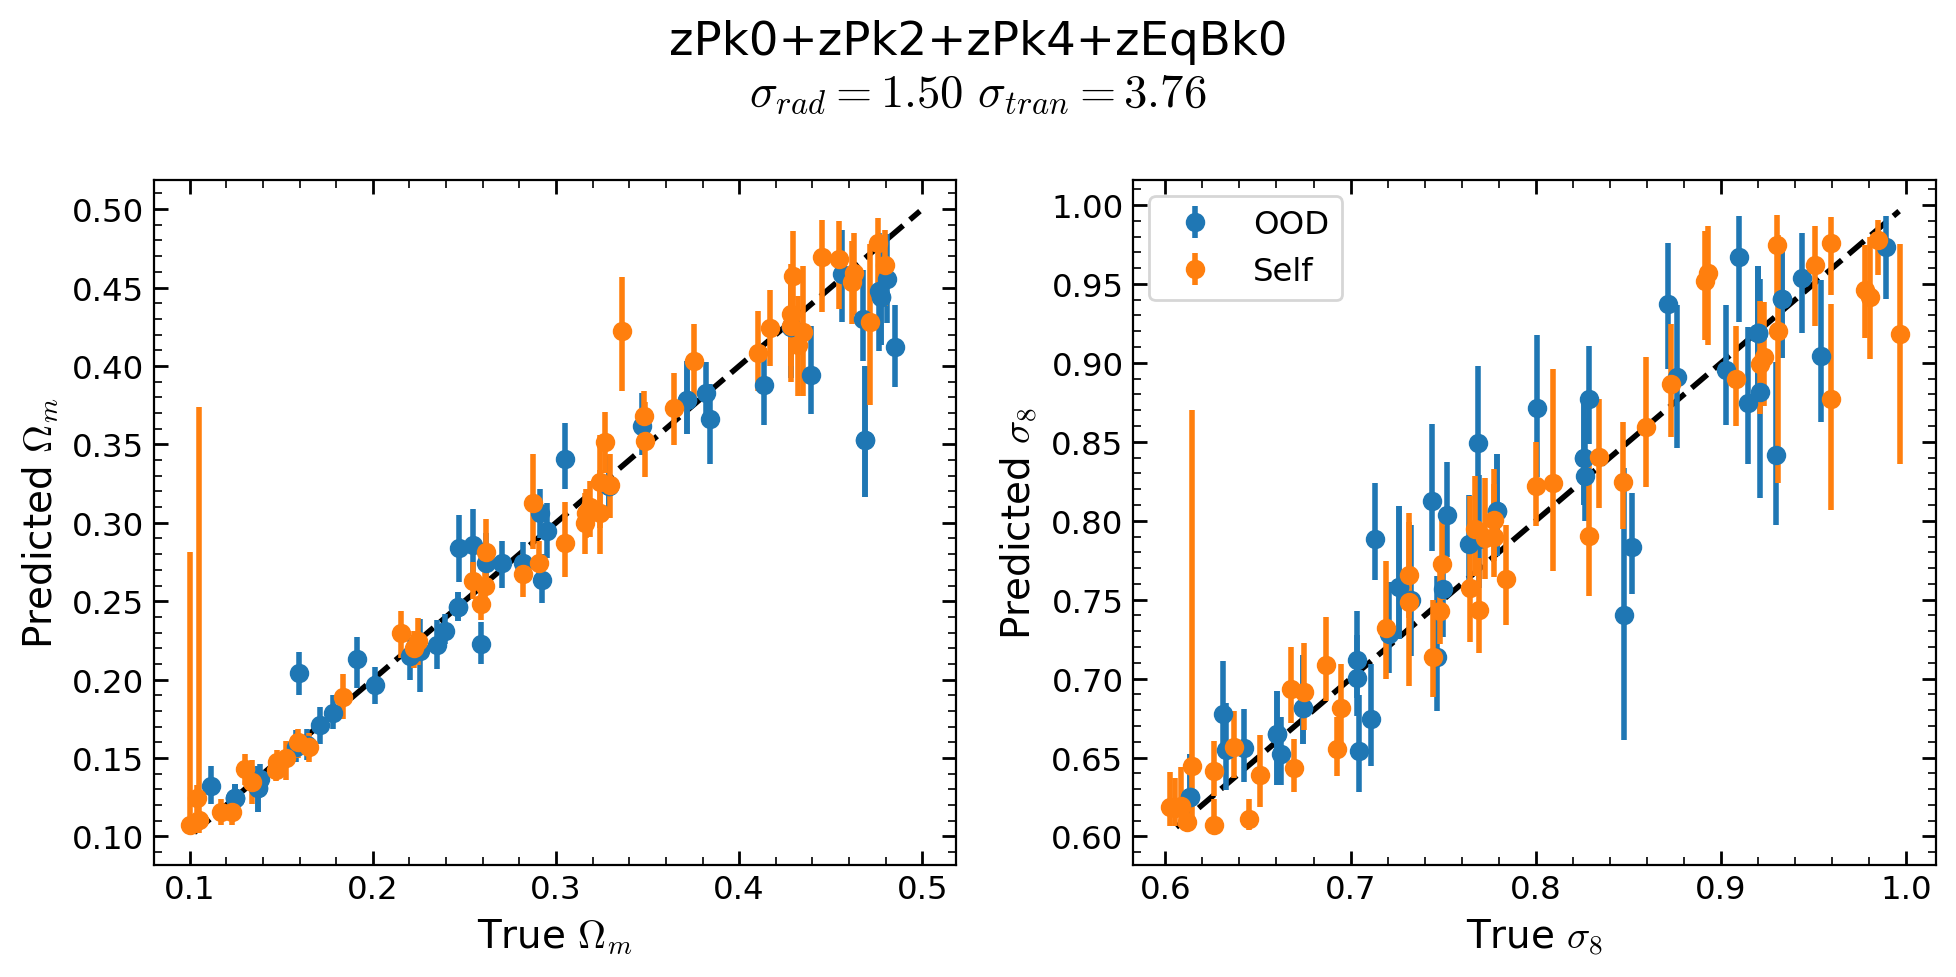

In [4]:
n = 37
Nplot = 50
idx = np.argwhere(noiseidx == n).flatten()
np.random.seed(42)
idx = np.random.choice(idx, Nplot)
idx_self = np.random.choice(len(theta_self), Nplot)
print(len(idx))

minmax = theta.min(axis=0), theta.max(axis=0)
minmax = np.array(minmax)
names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]

f, axs = plt.subplots(1, 2, figsize=(10, 5))
for i, j in enumerate([0, 4]):
    ax = axs[i]
    ax.plot(minmax[[0, 1], j], minmax[[0, 1], j], 'k--')
    ax.errorbar(
        theta[idx, j],
        percs[0][idx, j],
        yerr=[percs[1][idx, j], percs[2][idx, j]],
        fmt='o', label='OOD')
    ax.errorbar(
        theta_self[idx_self, j],
        percs_self[0][idx_self, j],
        yerr=[percs_self[1][idx_self, j], percs_self[2][idx_self, j]],
        fmt='o', label='Self')
    ax.set(xlabel=f'True ${names[j]}$', ylabel=f'Predicted ${names[j]}$')

ax.legend()
f.suptitle(
    f'{s}\n$\sigma_{{rad}}={noises[n,0]:.2f}$ $\sigma_{{tran}}={noises[n,1]:.2f}$')
plt.tight_layout()

208


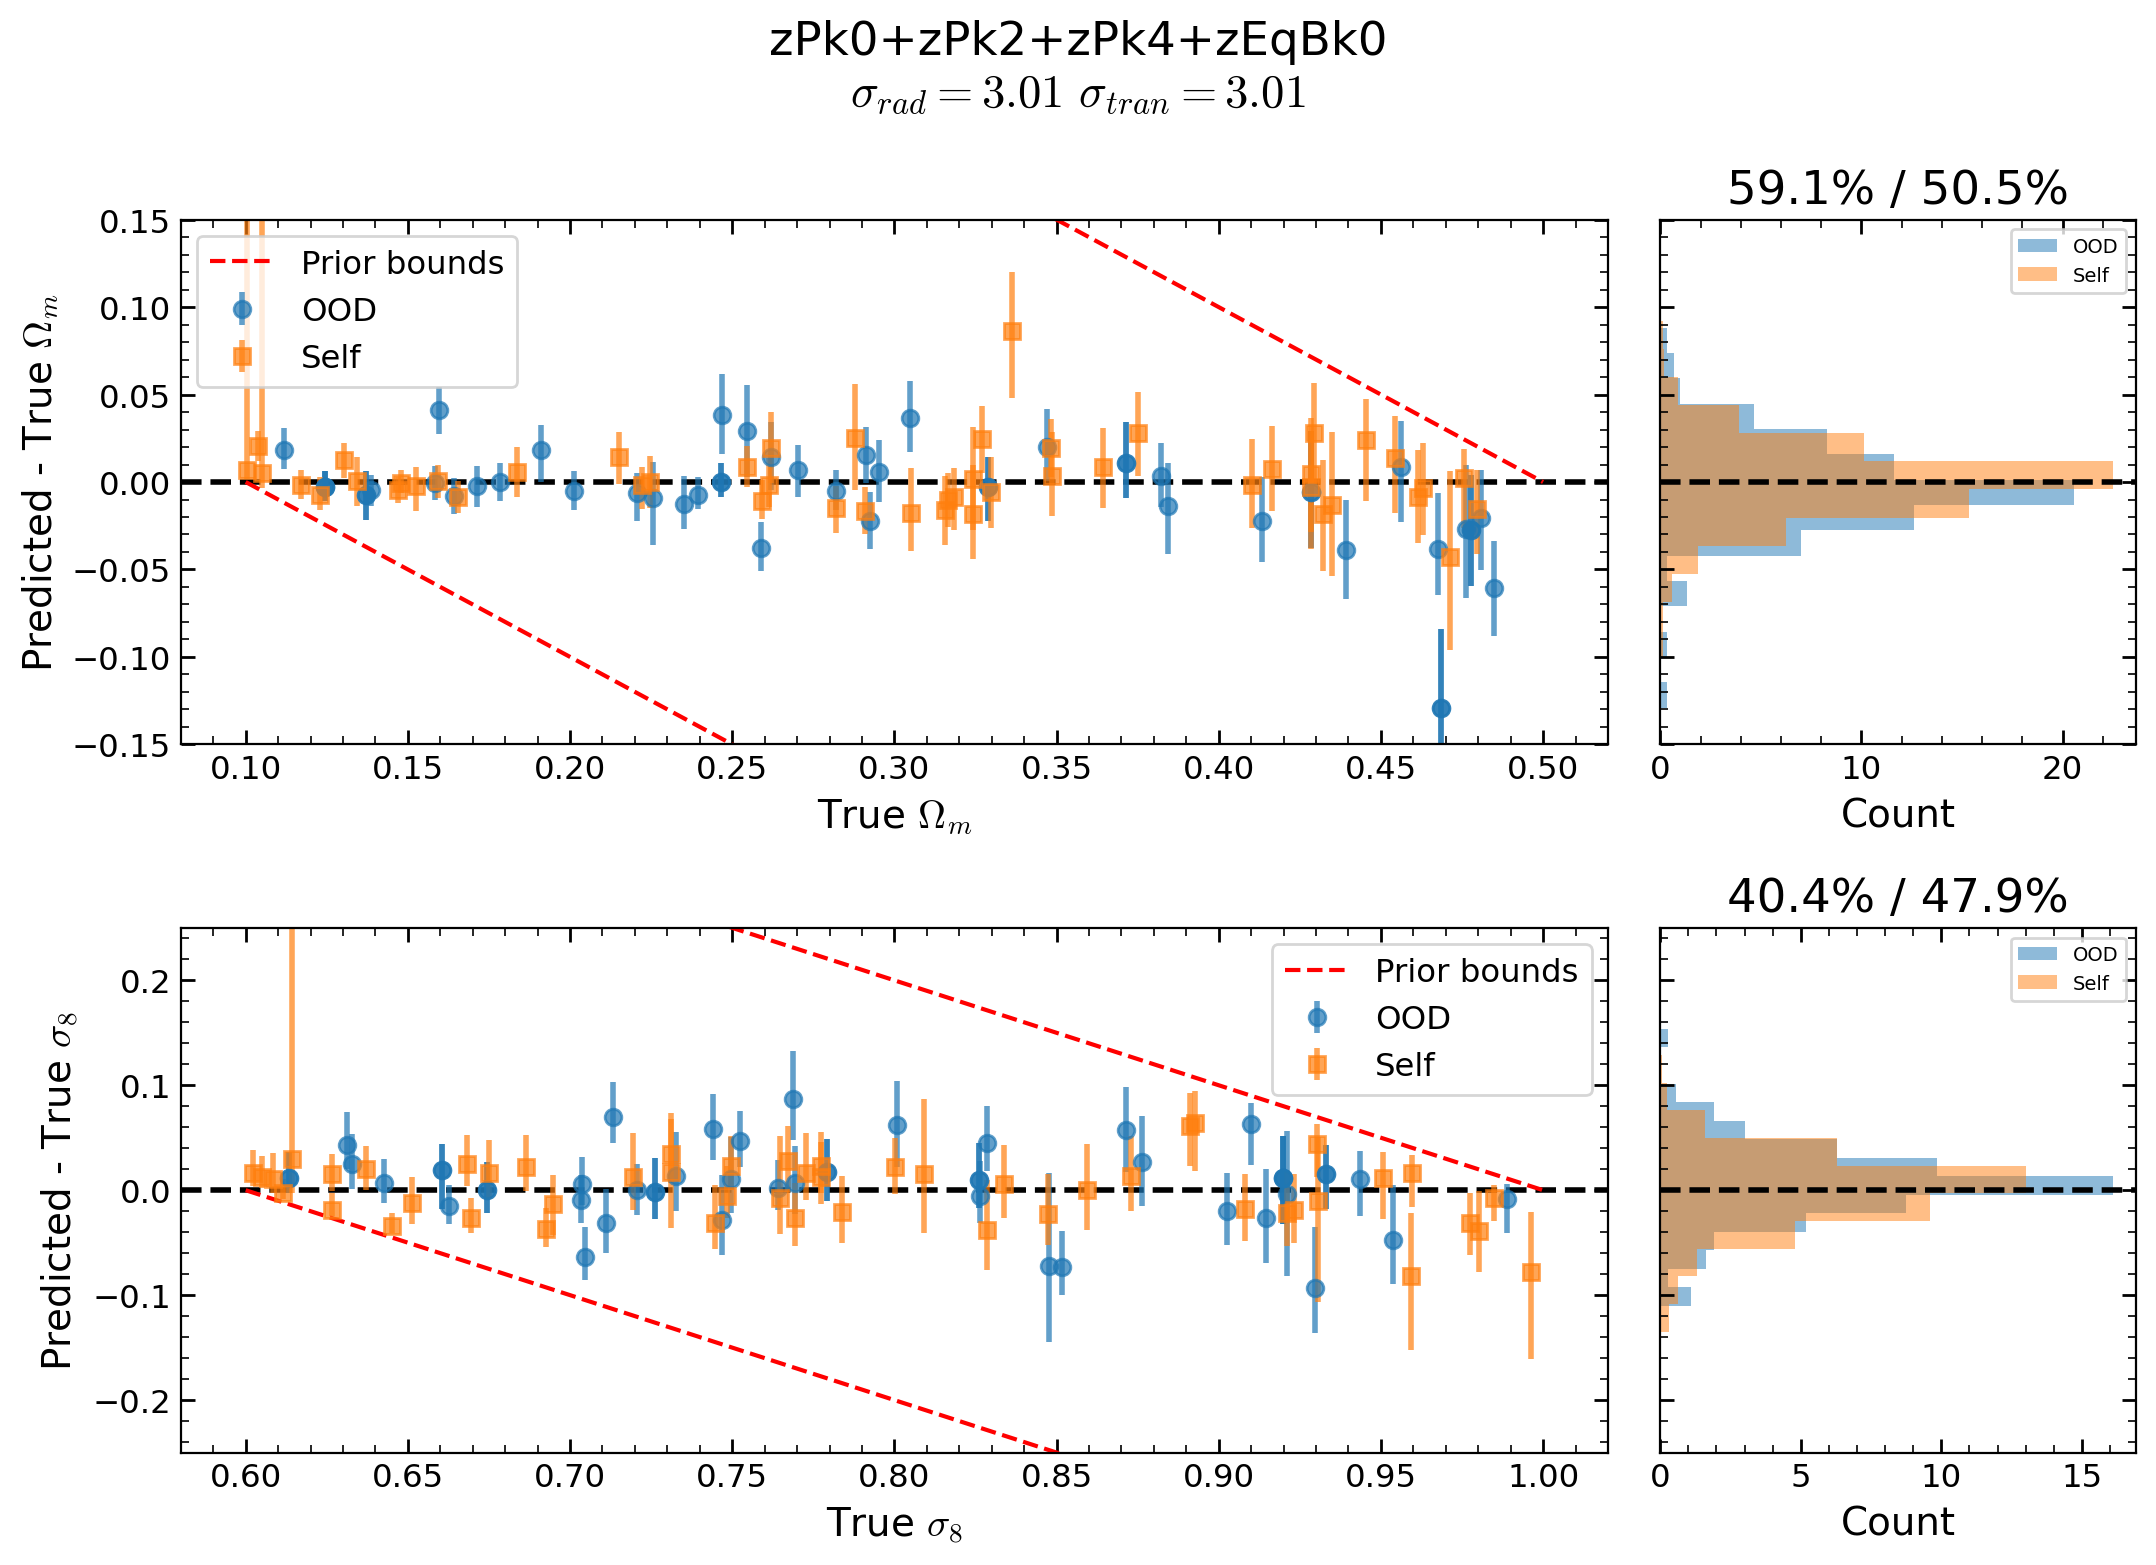

In [5]:
n = 32
Nplot = 50
idx_all = np.argwhere(noiseidx == n).flatten()
np.random.seed(42)
idx_plot = np.random.choice(idx_all, Nplot)
print(len(idx_all))

names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]
priors = {0: (0.1, 0.5), 4: (0.6, 1.0)}

idx_self_all = np.arange(len(theta_self))
idx_self_plot = np.random.choice(idx_self_all, Nplot)

fig, axs = plt.subplots(2, 2, figsize=(11, 8),
                        gridspec_kw={'width_ratios': [3, 1]},
                        sharey='row')

for i, j in enumerate([0, 4]):
    residuals_all = percs[0][idx_all, j] - theta[idx_all, j]
    residuals_plot = percs[0][idx_plot, j] - theta[idx_plot, j]
    residuals_self_all = percs_self[0][idx_self_all,
                                       j] - theta_self[idx_self_all, j]
    residuals_self_plot = percs_self[0][idx_self_plot,
                                        j] - theta_self[idx_self_plot, j]
    lo, hi = priors[j]

    ax = axs[i, 0]
    ax.axhline(0, c='k', ls='--')
    ax.errorbar(
        theta[idx_plot, j],
        residuals_plot,
        yerr=[percs[1][idx_plot, j], percs[2][idx_plot, j]],
        fmt='o', label='OOD', alpha=0.7)
    ax.errorbar(
        theta_self[idx_self_plot, j],
        residuals_self_plot,
        yerr=[percs_self[1][idx_self_plot, j], percs_self[2][idx_self_plot, j]],
        fmt='s', label='Self', alpha=0.7)

    true_range = np.linspace(lo, hi, 100)
    ax.plot(true_range, lo - true_range, 'r--', lw=1.5, label='Prior bounds')
    ax.plot(true_range, hi - true_range, 'r--', lw=1.5)

    ax.set(xlabel=f'True ${names[j]}$', ylabel=f'Predicted - True ${names[j]}$')
    ax.legend()

    ax_hist = axs[i, 1]
    ax_hist.hist(residuals_all, bins=15, orientation='horizontal',
                 alpha=0.5, label='OOD', density=True)
    ax_hist.hist(residuals_self_all, bins=15,
                 orientation='horizontal', alpha=0.5, label='Self', density=True)
    ax_hist.axhline(0, c='k', ls='--')
    ax_hist.set_xlabel('Count')
    ax_hist.tick_params(labelleft=False)
    medcoverage = np.sum(residuals_all < 0)/len(residuals_all)
    medcoverage_self = np.sum(residuals_self_all < 0)/len(residuals_self_all)
    ax_hist.set_title(f'{medcoverage*100:.1f}% / {medcoverage_self*100:.1f}%')
    ax_hist.legend(fontsize=7)

    if i == 0:
        ax.set_ylim(-0.15, 0.15)
    else:
        ax.set_ylim(-0.25, 0.25)

fig.suptitle(
    f'{s}\n$\sigma_{{rad}}={noises[n,0]:.2f}$ $\sigma_{{tran}}={noises[n,1]:.2f}$')
plt.tight_layout()

100%|██████████| 49/49 [00:00<00:00, 359.04it/s]


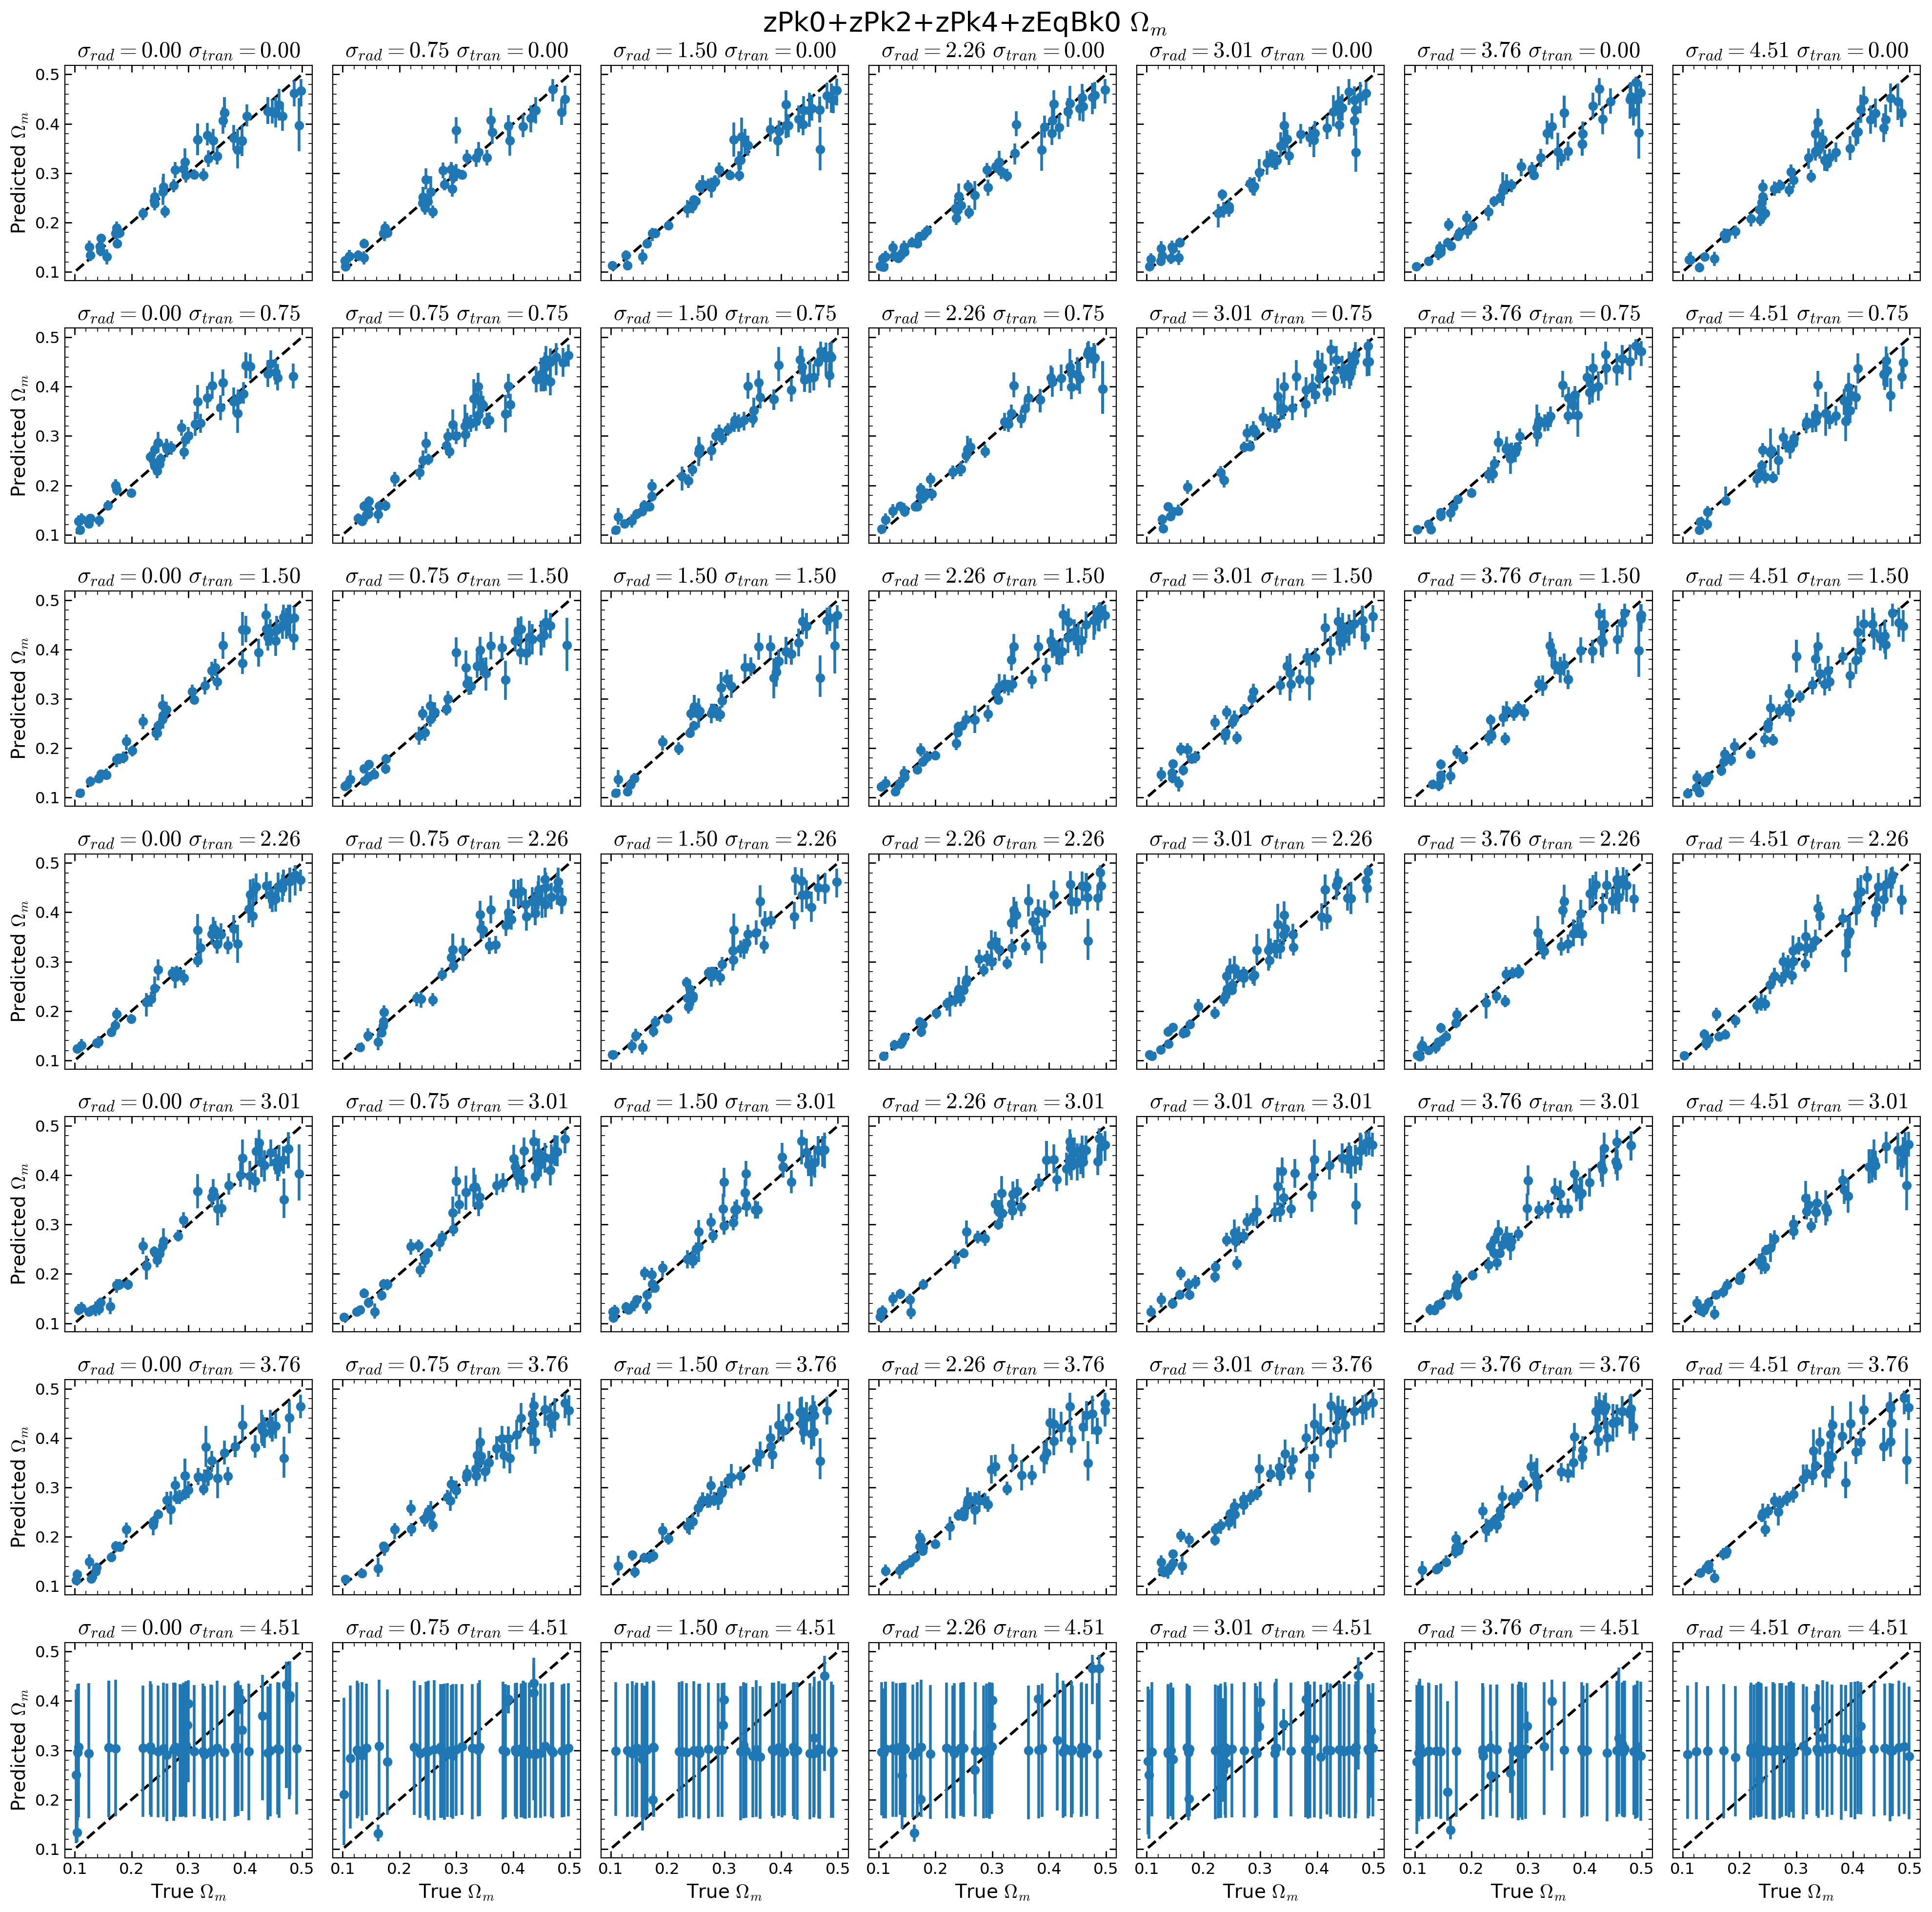

In [6]:
idx = np.random.choice(range(len(theta)), 100)
idx_self = np.random.choice(len(theta_self), Nplot)


minmax = theta.min(axis=0), theta.max(axis=0)
minmax = np.array(minmax)
names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]

f, axs = plt.subplots(7, 7, figsize=(20, 20), sharex=True, sharey=True)
axs = axs.flatten()
p = 0
for i in tqdm(range(49)):
    n = i
    idx = np.argwhere(noiseidx == n).flatten()
    idx = np.random.choice(idx, 50)

    ax = axs[i]
    ax.plot(minmax[[0, 1], p], minmax[[0, 1], p], 'k--')
    ax.errorbar(
        theta[idx, p],
        percs[0][idx, p],
        yerr=[percs[1][idx, p], percs[2][idx, p]],
        fmt='o')
    # ax.errorbar(
    #     theta_self[idx_self, p],
    #     percs_self[0][idx_self, p],
    #     yerr=[percs_self[1][idx_self, p], percs_self[2][idx_self, p]],
    #     fmt='s'
    # )
    ax.set_title(
        f'$\sigma_{{rad}}={noises[n,0]:.2f}$ $\sigma_{{tran}}={noises[n,1]:.2f}$')
    if i % 7 == 0:
        ax.set(ylabel=f'Predicted ${names[p]}$')
    if i//7 == 6:
        ax.set(xlabel=f'True ${names[p]}$')

f.suptitle(f'{s} ${names[p]}$', fontsize=20)
plt.tight_layout()

100%|██████████| 49/49 [00:00<00:00, 358.63it/s]


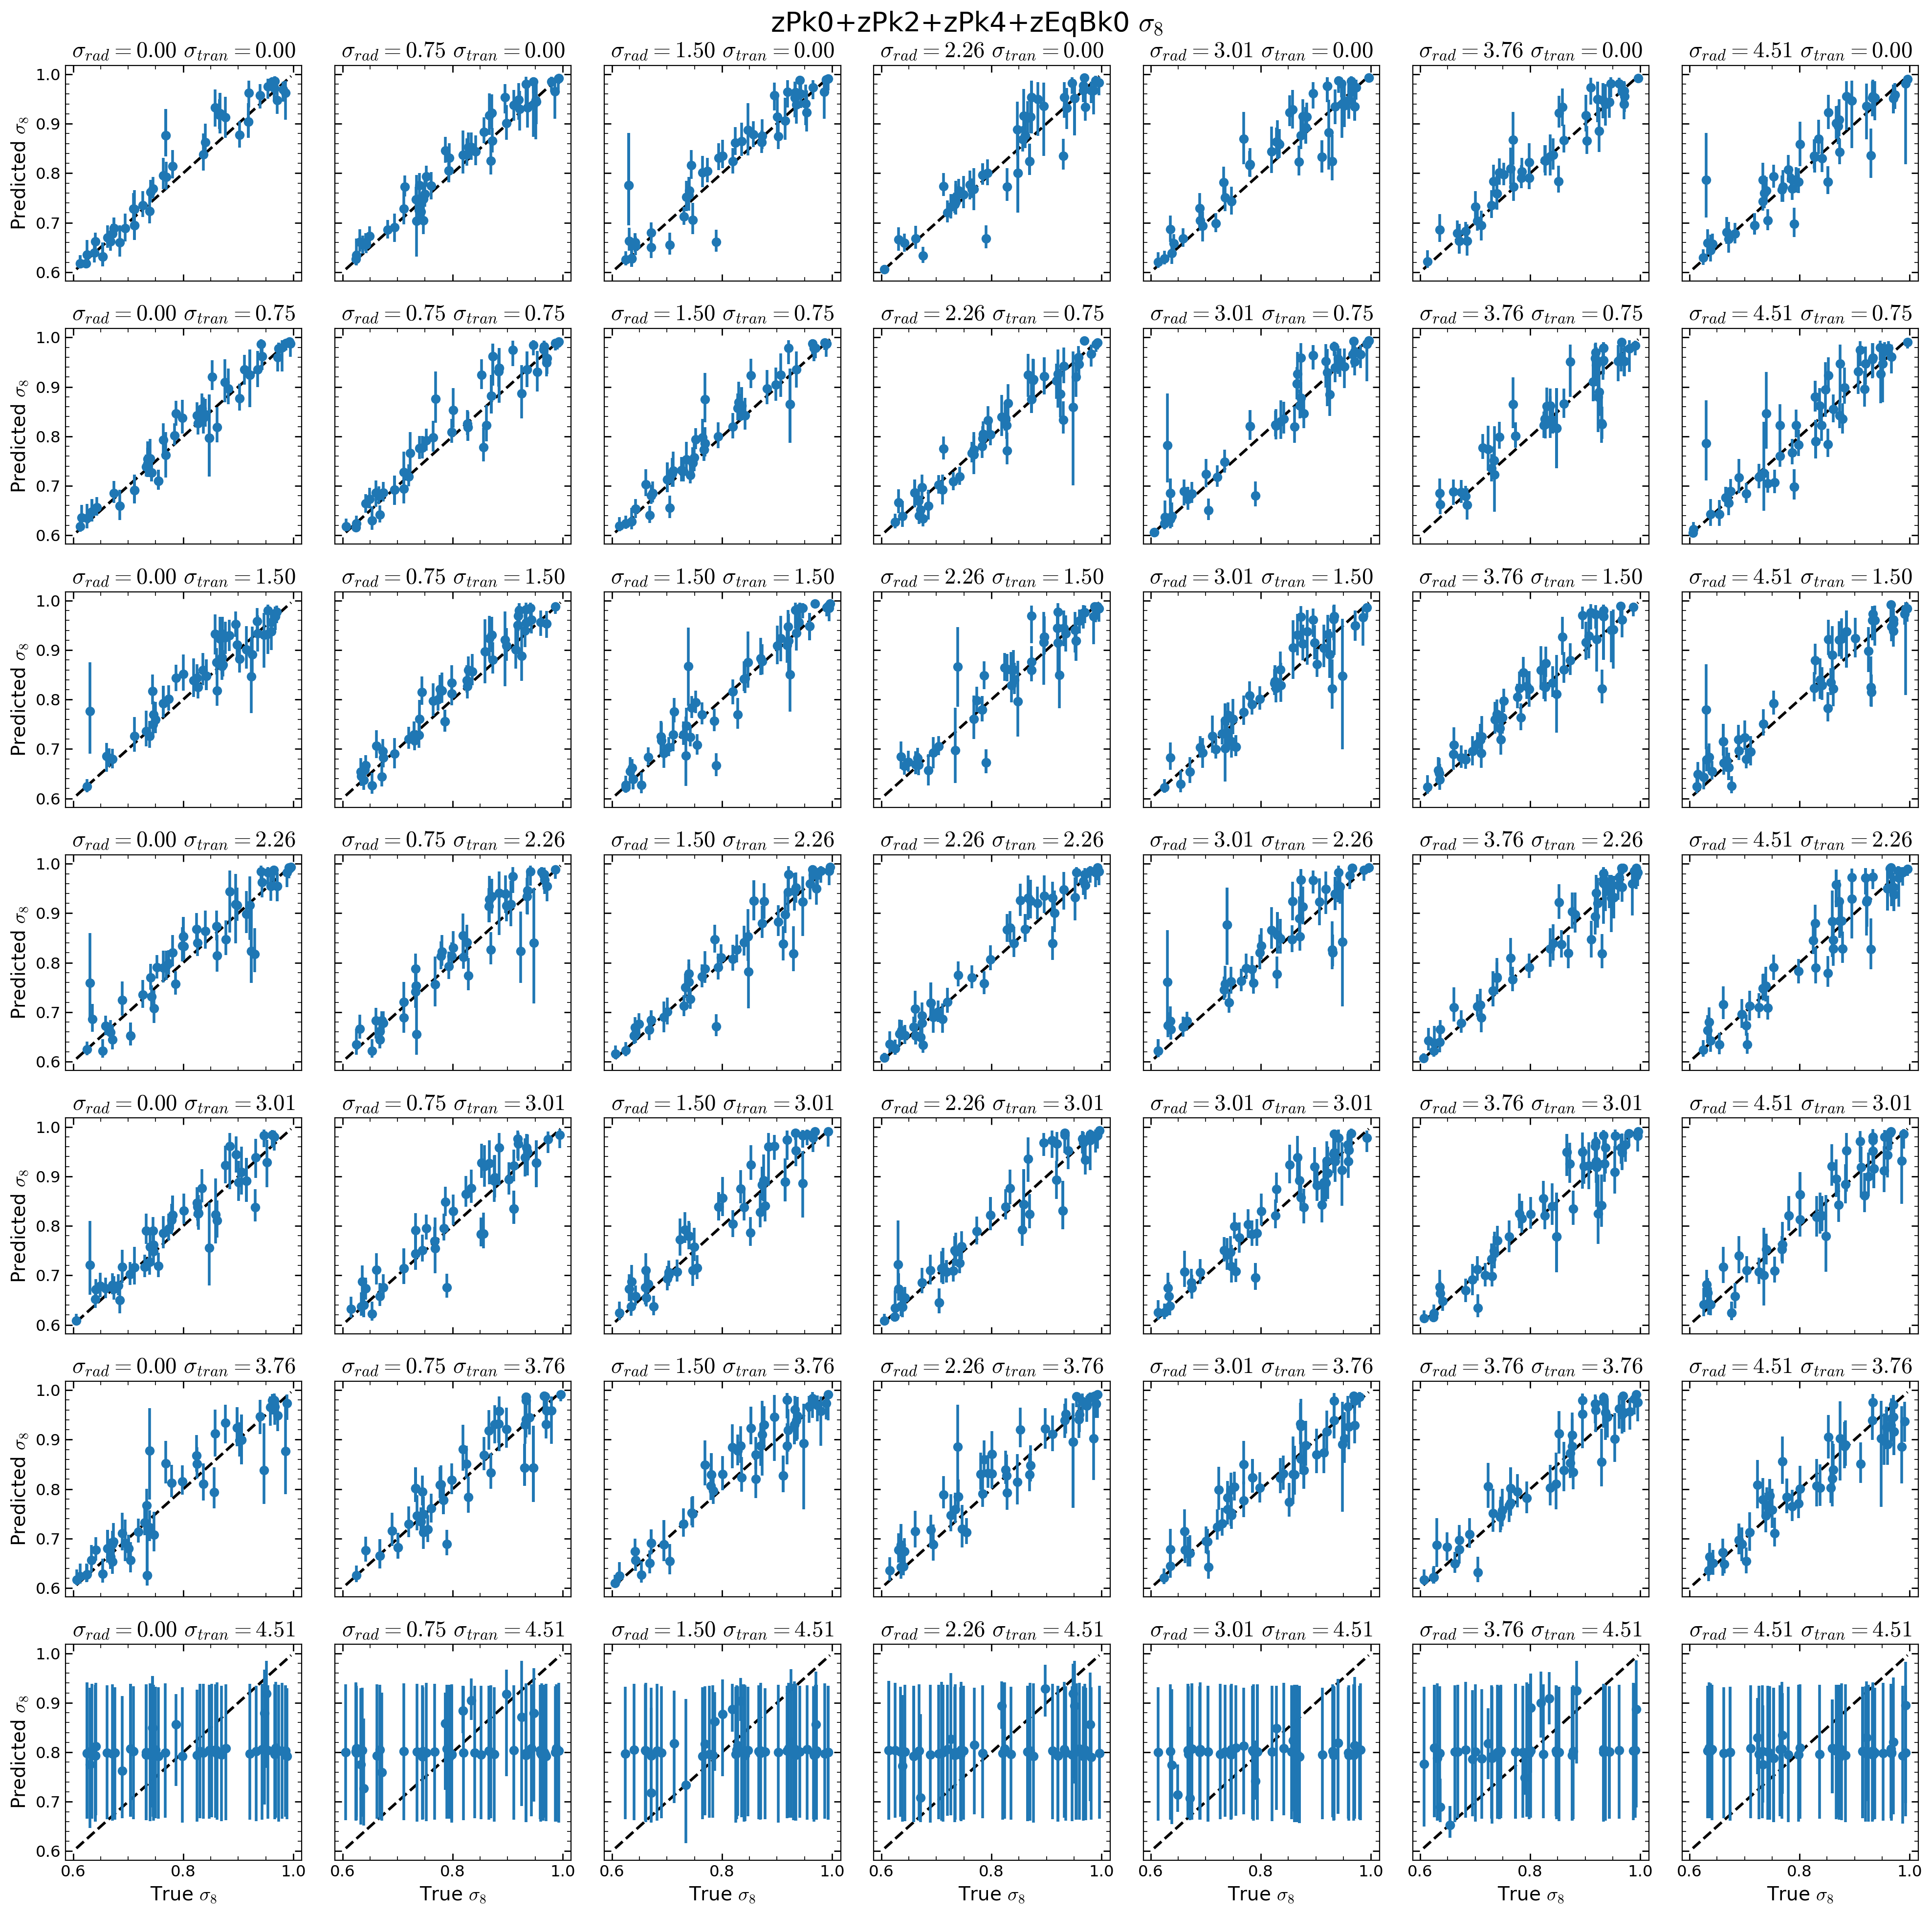

In [7]:
idx = np.random.choice(range(len(theta)), 100)
idx_self = np.random.choice(len(theta_self), Nplot)


minmax = theta.min(axis=0), theta.max(axis=0)
minmax = np.array(minmax)
names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]

f, axs = plt.subplots(7, 7, figsize=(20, 20), sharex=True, sharey=True)
axs = axs.flatten()
p = 4
for i in tqdm(range(49)):
    n = i
    idx = np.argwhere(noiseidx == n).flatten()
    idx = np.random.choice(idx, 50)

    ax = axs[i]
    ax.plot(minmax[[0, 1], p], minmax[[0, 1], p], 'k--')
    ax.errorbar(
        theta[idx, p],
        percs[0][idx, p],
        yerr=[percs[1][idx, p], percs[2][idx, p]],
        fmt='o')
    # ax.errorbar(
    #     theta_self[idx_self, p],
    #     percs_self[0][idx_self, p],
    #     yerr=[percs_self[1][idx_self, p], percs_self[2][idx_self, p]],
    #     fmt='s'
    # )
    ax.set_title(
        f'$\sigma_{{rad}}={noises[n,0]:.2f}$ $\sigma_{{tran}}={noises[n,1]:.2f}$')
    if i % 7 == 0:
        ax.set(ylabel=f'Predicted ${names[p]}$')
    if i//7 == 6:
        ax.set(xlabel=f'True ${names[p]}$')

f.suptitle(f'{s} ${names[p]}$', fontsize=20)
plt.tight_layout()

In [8]:
def marginal_coverage(samples: np.ndarray, trues: np.ndarray, nbins: int = 20):
    valid = np.isfinite(samples)
    num_samples = valid.sum(axis=0)          # (num_data,)
    num_data = trues.shape[0]

    ranks = ((samples < trues[None, :]) & valid).sum(
        axis=0) / num_samples  # PIT values

    bin_edges = np.linspace(0, 1, nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Evaluate empirical CDF at bin_centers, not bin right-edges
    coverage = (ranks[None, :] <= bin_centers[:, None]).mean(axis=1)
    error = np.sqrt(coverage * (1 - coverage) / num_data)

    return bin_centers, coverage, error

  2%|▏         | 1/49 [00:00<00:05,  8.74it/s]

100%|██████████| 49/49 [00:01<00:00, 27.59it/s]


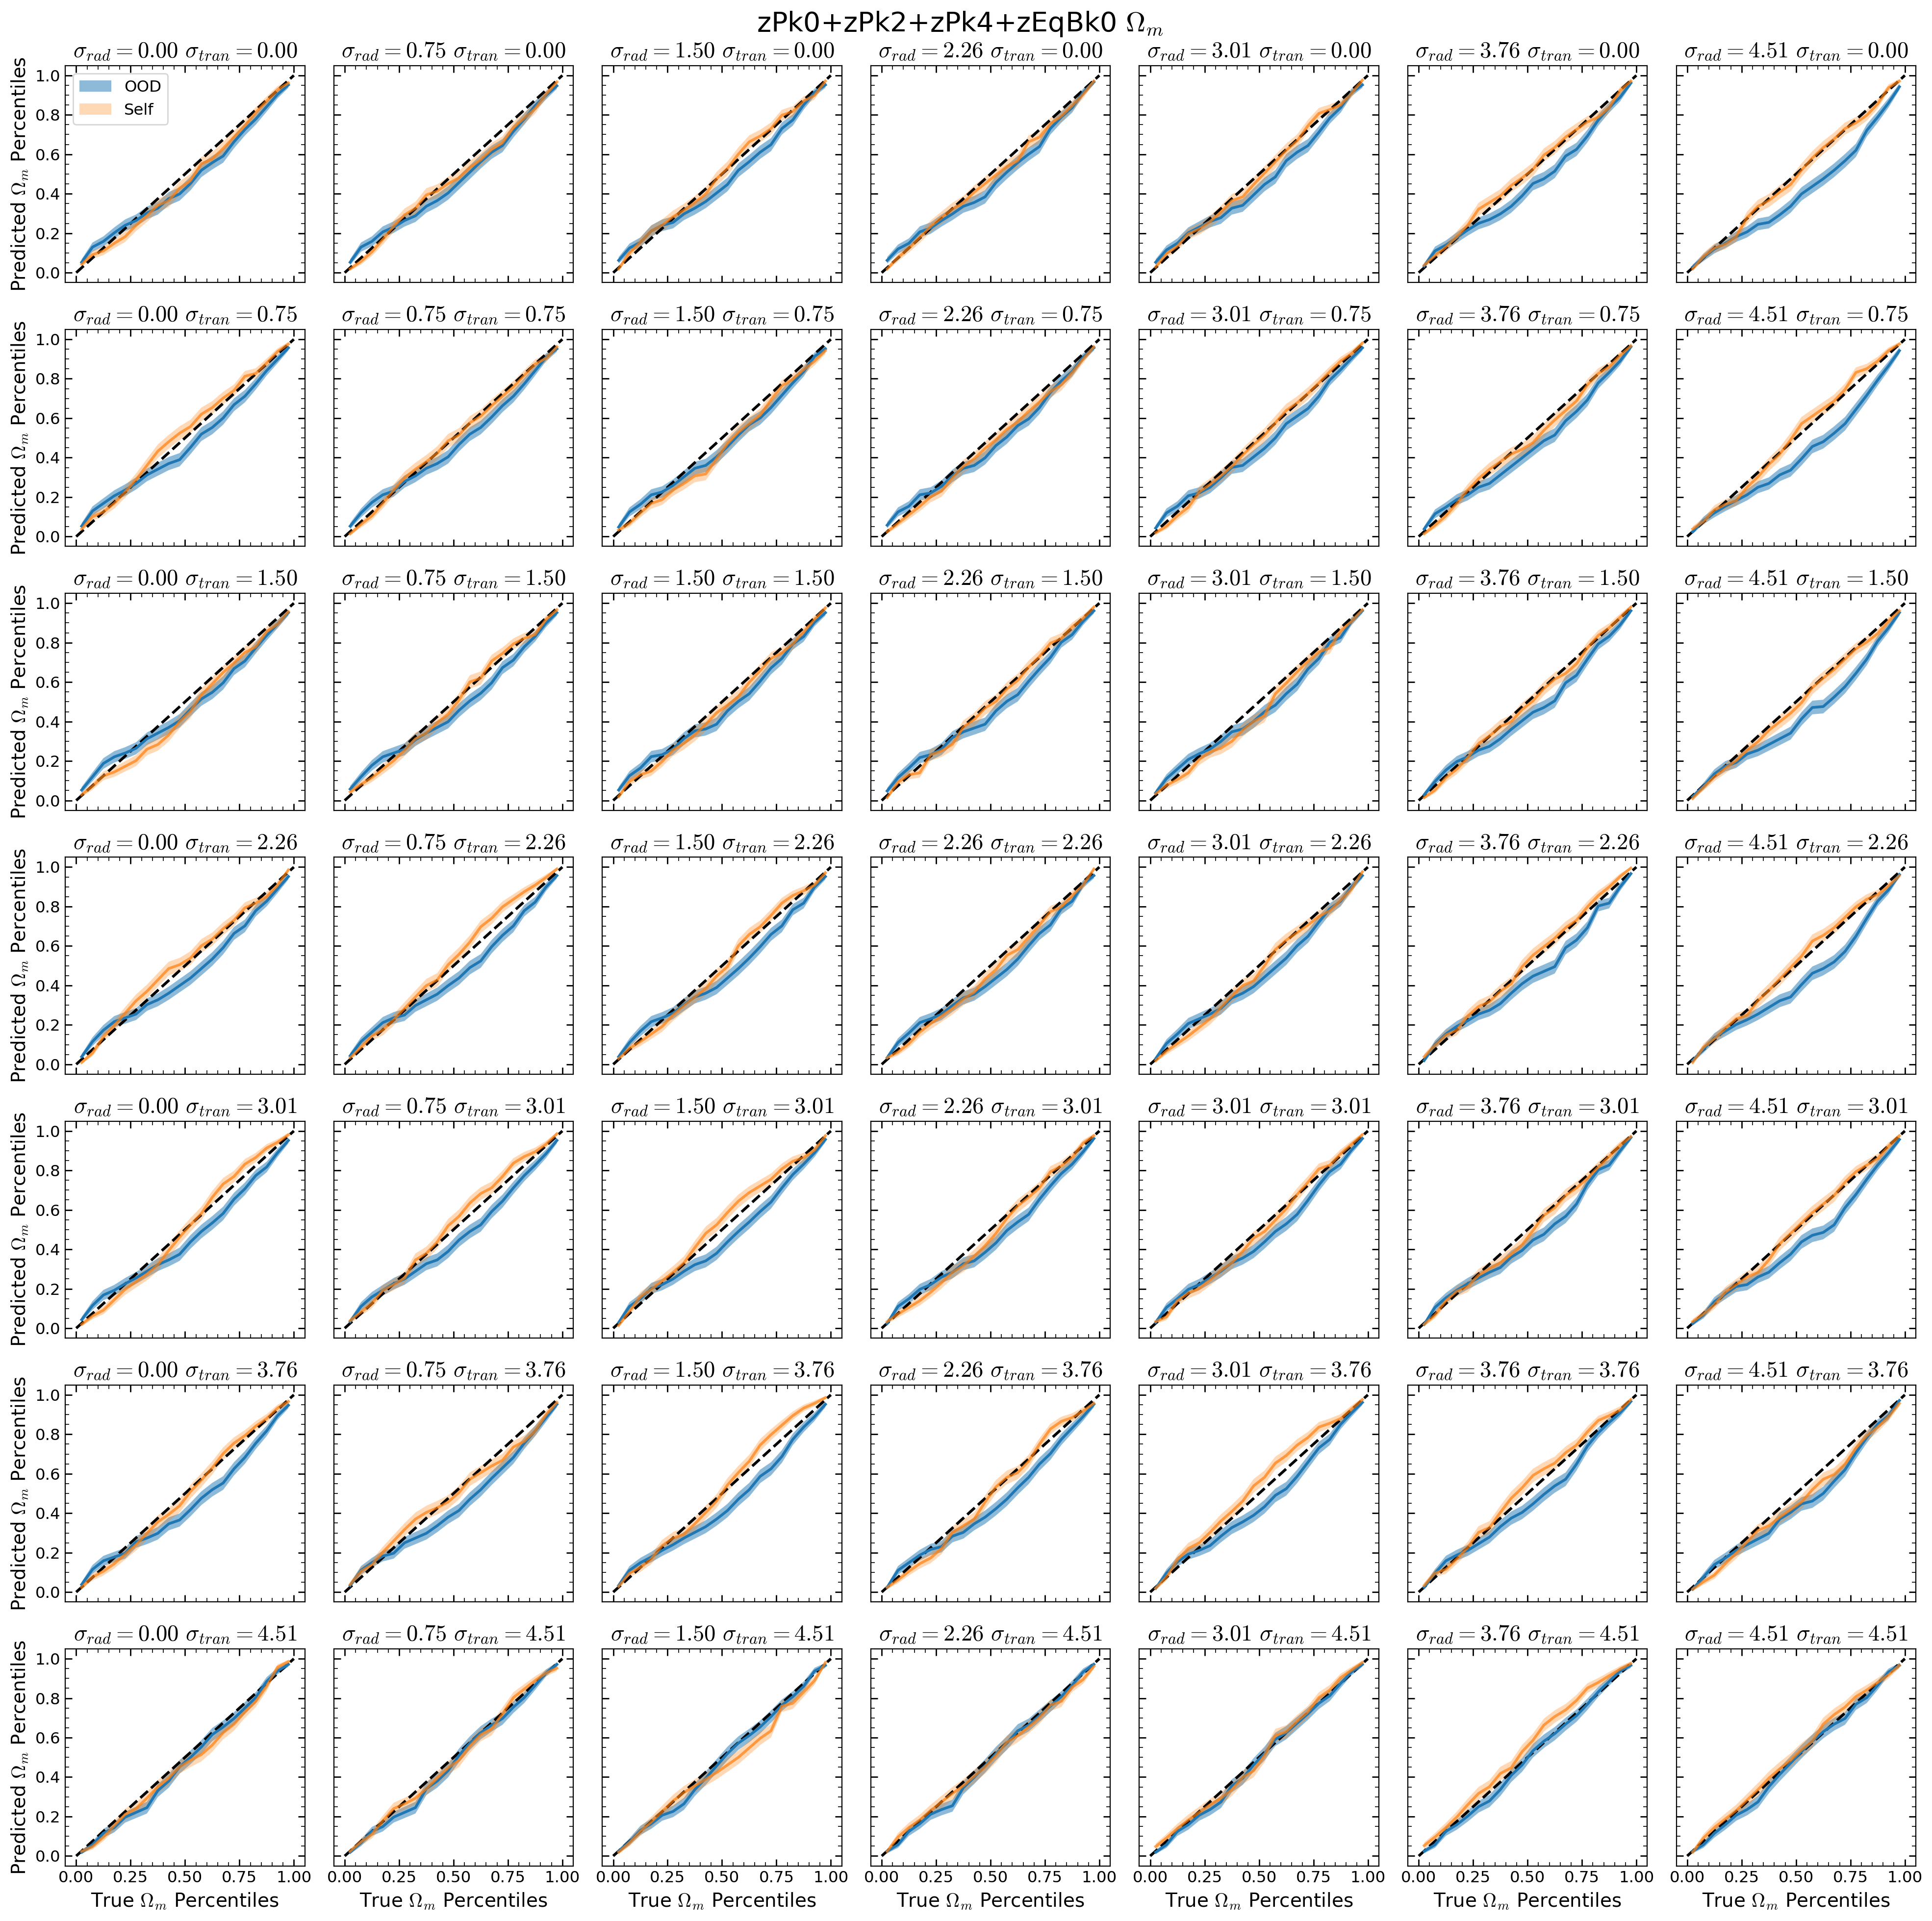

In [9]:
names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]


f, axs = plt.subplots(7, 7, figsize=(20, 20), sharex=True, sharey=True)
axs = axs.flatten()
p = 0
for i in tqdm(range(49)):
    ax = axs[i]
    n = i
    idx = np.argwhere(noiseidx == n).flatten()
    idx_self = np.random.choice(len(theta_self), len(idx))

    # plot OOD
    _x, _y, _err = marginal_coverage(samples[:, idx, p], theta[idx, p])
    ax.plot([0, 1], [0, 1], 'k--')
    ax.plot(_x, _y)
    ax.fill_between(_x, _y - _err, _y + _err, alpha=0.5, label='OOD')

    # plot self
    _x, _y, _err = marginal_coverage(
        samples_self[:, idx_self, p], theta_self[idx_self, p])
    ax.plot(_x, _y, alpha=0.7)
    ax.fill_between(_x, _y - _err, _y + _err, alpha=0.3, label='Self')

    ax.set_title(
        f'$\sigma_{{rad}}={noises[n,0]:.2f}$ $\sigma_{{tran}}={noises[n,1]:.2f}$')
    if i % 7 == 0:
        ax.set(ylabel=f'Predicted ${names[p]}$ Percentiles')
    if i // 7 == 6:
        ax.set(xlabel=f'True ${names[p]}$ Percentiles')
    if i == 0:
        ax.legend()
f.suptitle(f'{s} ${names[p]}$', fontsize=20)
plt.tight_layout()

 49%|████▉     | 24/49 [00:00<00:00, 29.94it/s]

100%|██████████| 49/49 [00:01<00:00, 29.91it/s]


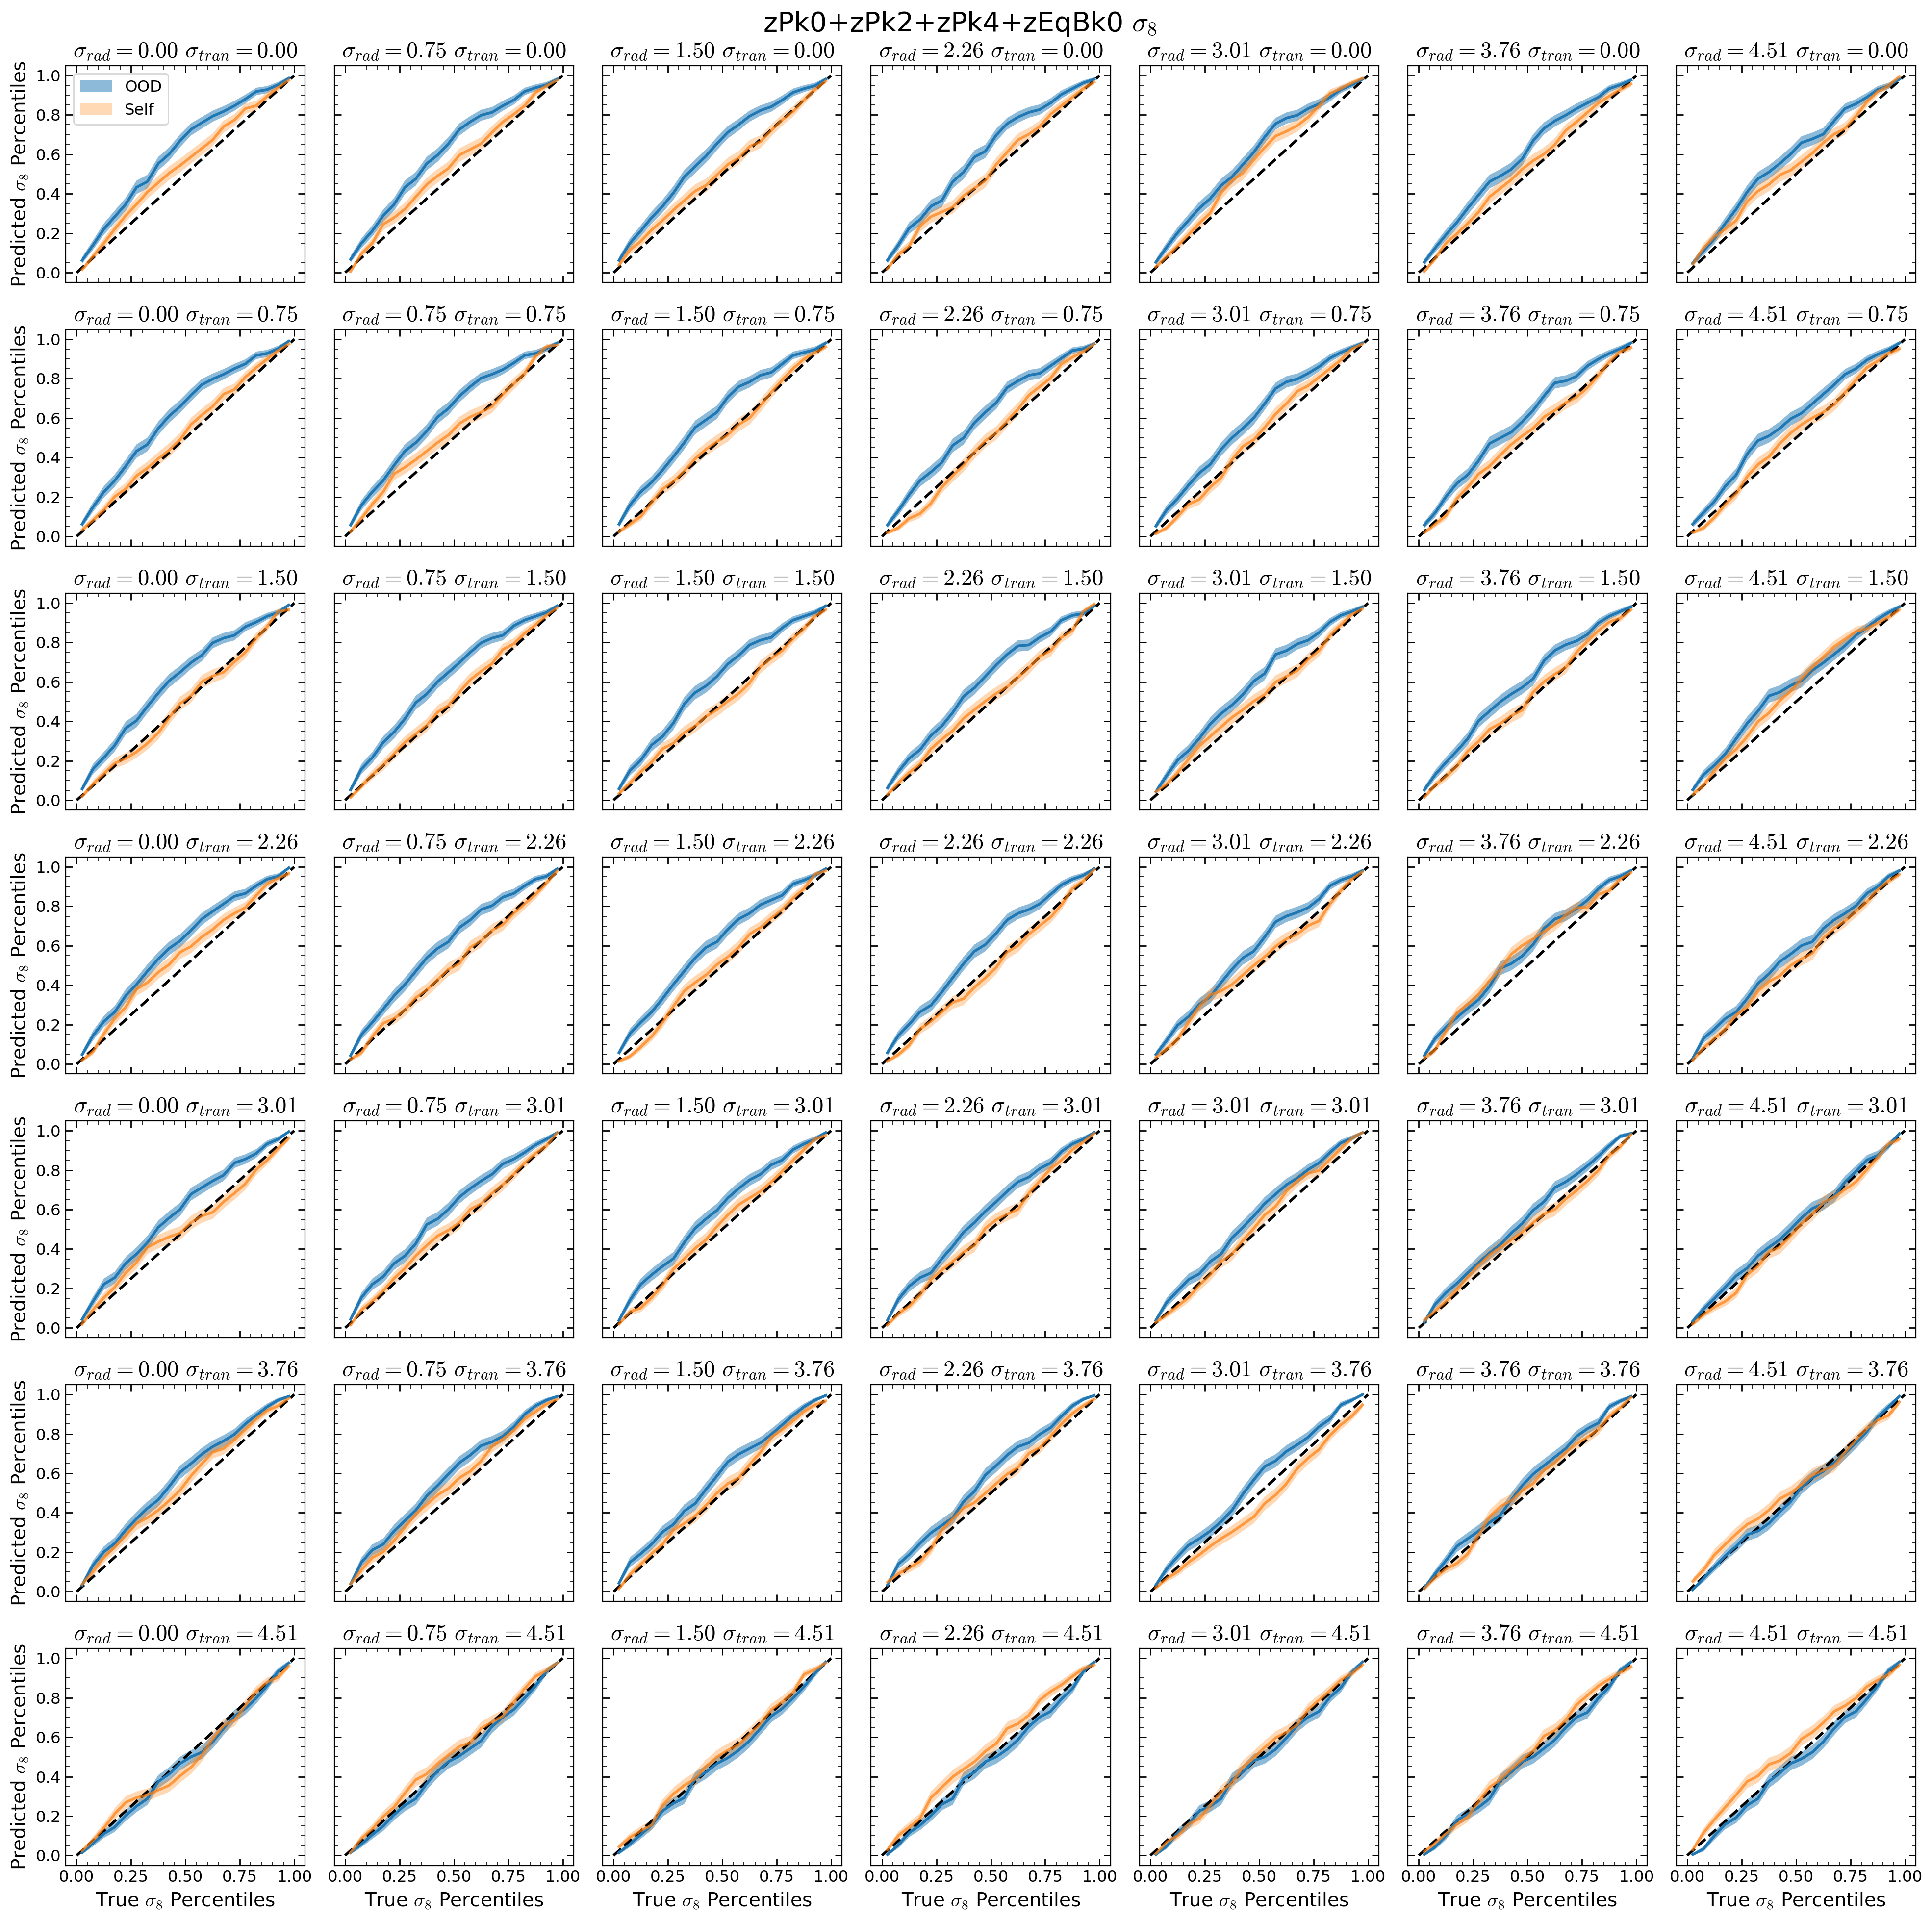

In [10]:
names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]


f, axs = plt.subplots(7, 7, figsize=(20, 20), sharex=True, sharey=True)
axs = axs.flatten()
p = 4
for i in tqdm(range(49)):
    ax = axs[i]
    n = i
    idx = np.argwhere(noiseidx == n).flatten()
    idx_self = np.random.choice(len(theta_self), len(idx))

    # plot OOD
    _x, _y, _err = marginal_coverage(samples[:, idx, p], theta[idx, p])
    ax.plot([0, 1], [0, 1], 'k--')
    ax.plot(_x, _y)
    ax.fill_between(_x, _y - _err, _y + _err, alpha=0.5, label='OOD')

    # plot self
    _x, _y, _err = marginal_coverage(
        samples_self[:, idx_self, p], theta_self[idx_self, p])
    ax.plot(_x, _y, alpha=0.7)
    ax.fill_between(_x, _y - _err, _y + _err, alpha=0.3, label='Self')

    ax.set_title(
        f'$\sigma_{{rad}}={noises[n,0]:.2f}$ $\sigma_{{tran}}={noises[n,1]:.2f}$')
    if i % 7 == 0:
        ax.set(ylabel=f'Predicted ${names[p]}$ Percentiles')
    if i // 7 == 6:
        ax.set(xlabel=f'True ${names[p]}$ Percentiles')
    if i == 0:
        ax.legend()
f.suptitle(f'{s} ${names[p]}$', fontsize=20)
plt.tight_layout()

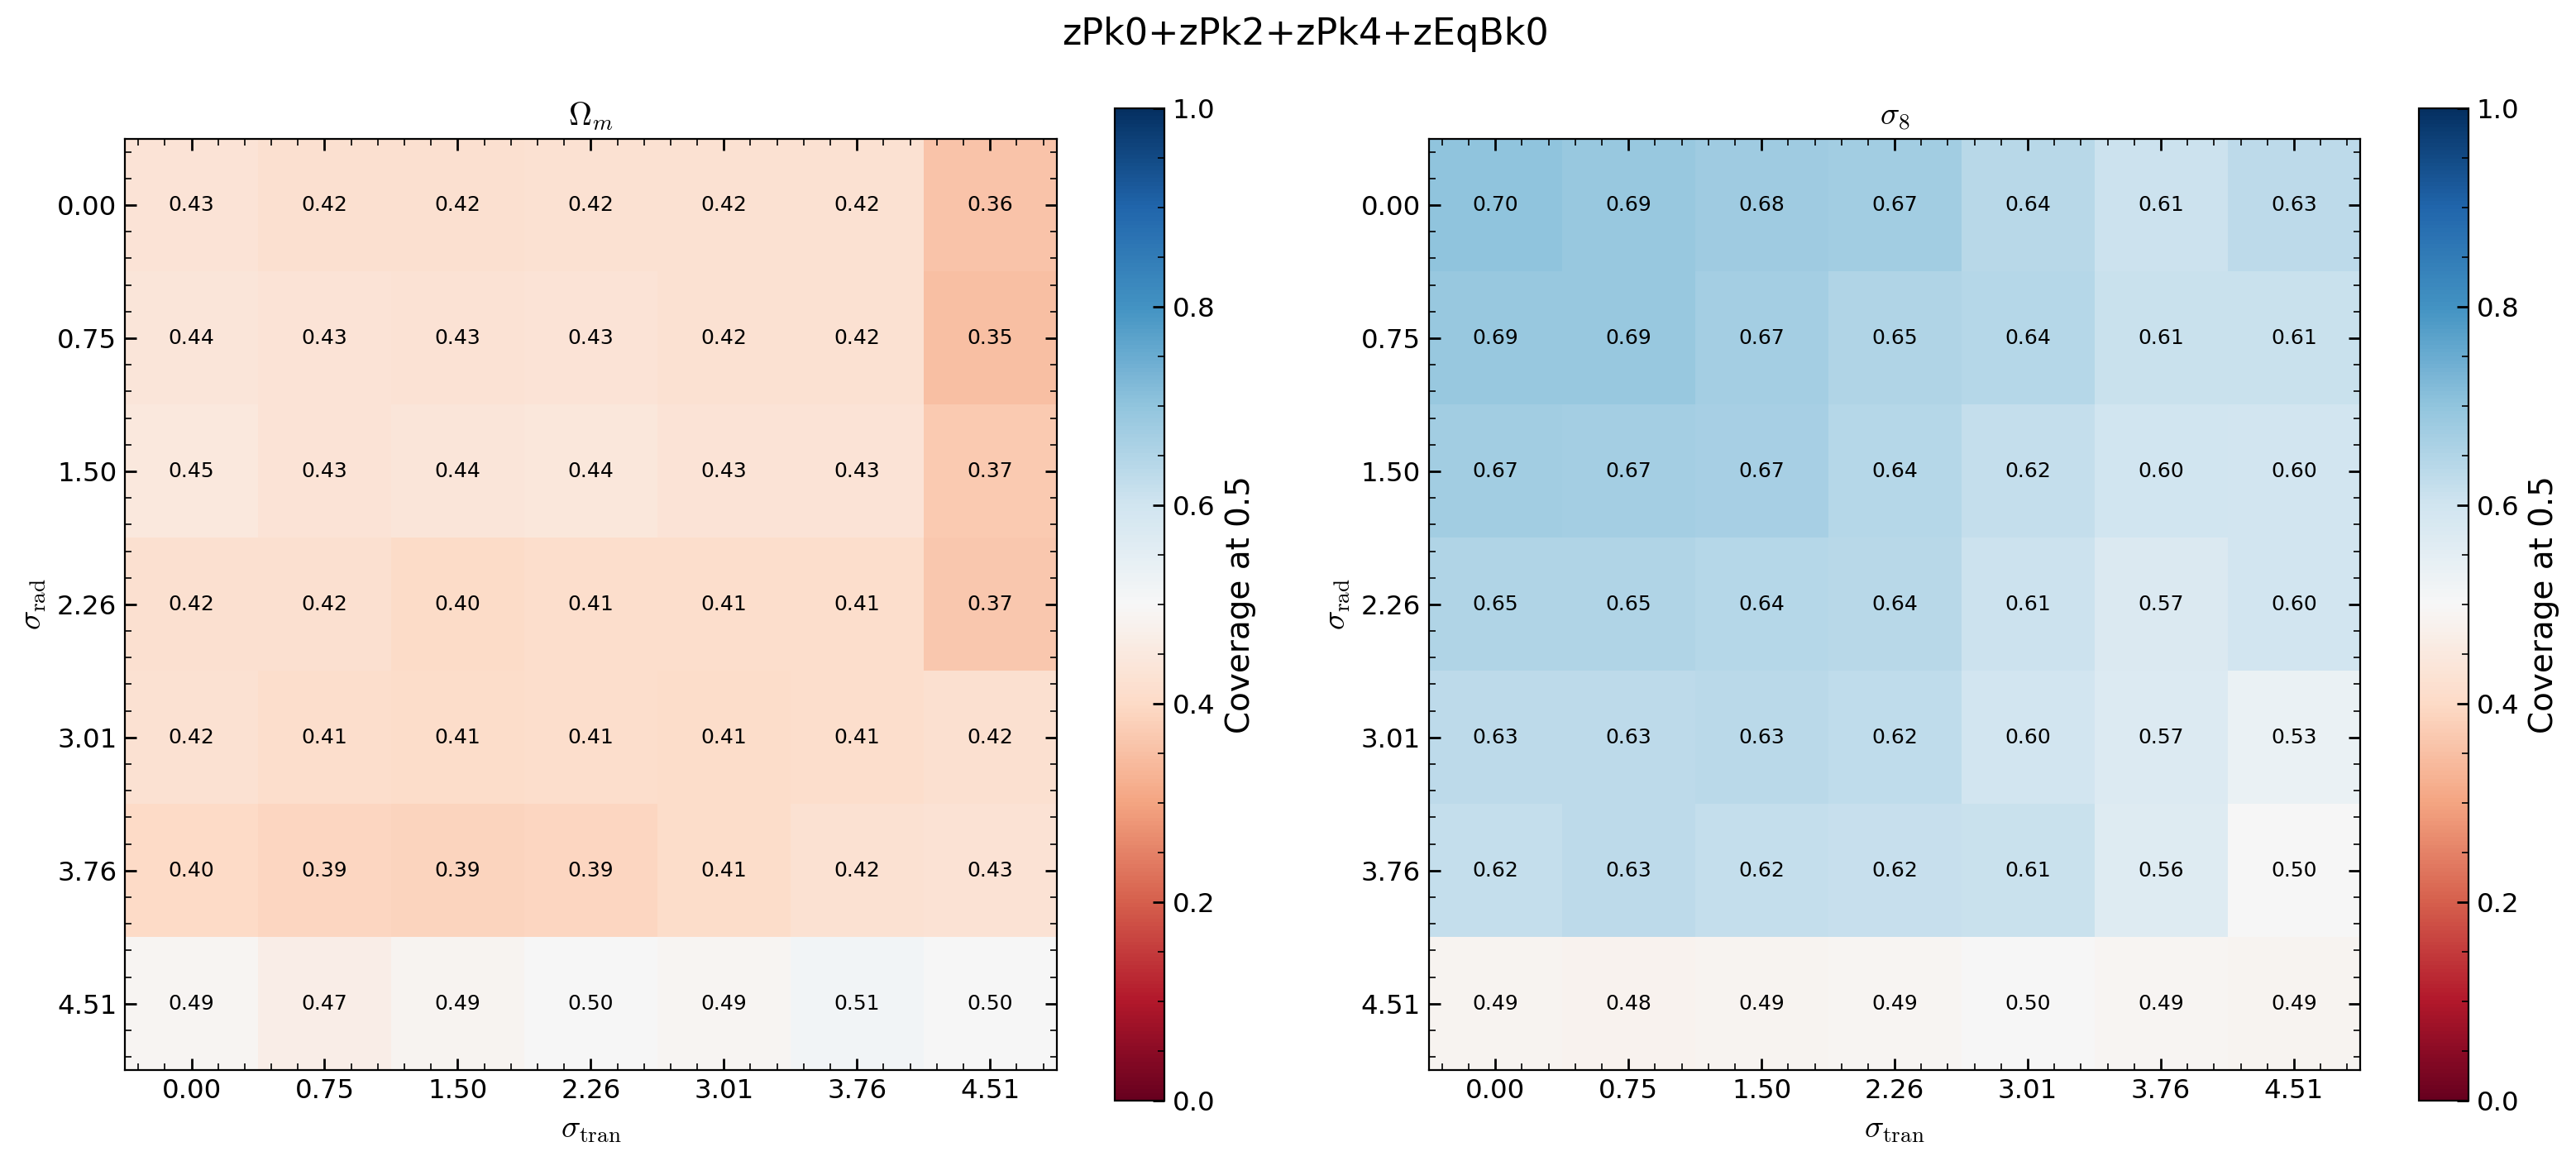

In [11]:
def median_coverage(samples: np.ndarray, trues: np.ndarray):
    """Fraction of times the true value falls below the posterior median."""
    medians = np.median(samples, axis=0)
    return (trues < medians).mean()


p = 4
heatmap = np.zeros((7, 7))
for i in range(49):
    row, col = divmod(i, 7)
    idx = np.argwhere(noiseidx == i).flatten()
    heatmap[row, col] = median_coverage(samples[:, idx, p], theta[idx, p])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, p in zip(axes, [0, 4]):
    heatmap = np.zeros((7, 7))
    for i in range(49):
        row, col = divmod(i, 7)
        idx = np.argwhere(noiseidx == i).flatten()
        heatmap[row, col] = median_coverage(samples[:, idx, p], theta[idx, p])

    im = ax.imshow(heatmap, vmin=0, vmax=1, cmap='RdBu', origin='upper')
    for i in range(7):
        for j in range(7):
            ax.text(j, i, f'{heatmap[i, j]:.2f}',
                    ha='center', va='center', fontsize=9)

    ax.set_xticks(range(7))
    ax.set_xticklabels([f'{noises[i*7, 1]:.2f}' for i in range(7)])
    ax.set_yticks(range(7))
    ax.set_yticklabels([f'{noises[j, 0]:.2f}' for j in range(7)])
    ax.set_xlabel(r'$\sigma_{\rm tran}$')
    ax.set_ylabel(r'$\sigma_{\rm rad}$')
    ax.set_title(f'${names[p]}$', fontsize=14)
    plt.colorbar(im, ax=ax, label='Coverage at 0.5')

fig.suptitle(f'{s}', fontsize=16)
plt.tight_layout()

### Restrict to a smaller prior range

Om \in [0.2,0.4]

s8 \in [0.7,0.9]

In [ ]:
basedir = '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_niall2/models/galaxy'
testdir = '/work/hdd/bdne/maho3/cmass-ili/quijote/nbody_gridnoise/models/galaxy'

sim = 'quijote_nbody_gridnoise'

slist = os.listdir(basedir)
slist = [x for x in slist if 'nbar' in x]
s = 'nbar+zPk0+zPk2+zPk4+zBk0'
print(s)

filepath = join(testdir, s, 'kmin-0.0_kmax-0.4', 'theta_test.npy')
theta = np.load(filepath)
filepath = join(testdir, s, 'kmin-0.0_kmax-0.4', 'ids_test.npy')
ids = np.load(filepath)
filepath = join(testdir, s, 'kmin-0.0_kmax-0.4', 'noiseids_test.npy')
noiseidx = np.load(filepath)[:, 0]

noises = np.loadtxt(
    '/work/hdd/bdne/maho3/cmass-ili/noise_priors/noisegrid.csv', delimiter=',')

filepath = join(basedir, s, 'kmin-0.0_kmax-0.4',
                'testing', sim, 'posterior_samples.npy')
samples = np.load(filepath)

print('theta before:', theta.shape)
mask = (theta[:, 0] > 0.2) & (theta[:, 0] < 0.4) & (
    theta[:, 4] > 0.7) & (theta[:, 4] < 0.9)
theta = theta[mask]
ids = ids[mask]
noiseidx = noiseidx[mask]
samples = samples[:, mask]
print('theta after:', theta.shape)

mask = (samples[..., 0] > 0.2) & (samples[..., 0] < 0.4) & (
    samples[..., 4] > 0.7) & (samples[..., 4] < 0.9)
samples[~mask, :] = np.nan

percs = np.nanpercentile(samples, q=[50, 16, 84], axis=0)
percs[1] = percs[0]-percs[1]
percs[2] = percs[2]-percs[0]

In [ ]:
n = 32
idx_all = np.argwhere(noiseidx == n).flatten()
np.random.seed(42)
idx_plot = np.random.choice(idx_all, 100)
print(len(idx_all))

names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]
priors = {0: (0.2, 0.4), 4: (0.7, 0.9)}

fig, axs = plt.subplots(2, 2, figsize=(11, 8),
                        gridspec_kw={'width_ratios': [3, 1]},
                        sharey='row')

for i, j in enumerate([0, 4]):
    residuals_all = percs[0][idx_all, j] - theta[idx_all, j]
    residuals_plot = percs[0][idx_plot, j] - theta[idx_plot, j]
    lo, hi = priors[j]

    # Left: errorbar plot (subsampled)
    ax = axs[i, 0]
    ax.axhline(0, c='k', ls='--')
    ax.errorbar(
        theta[idx_plot, j],
        residuals_plot,
        yerr=[percs[1][idx_plot, j], percs[2][idx_plot, j]],
        fmt='o')

    # Prior boundary lines: predicted = lo or hi => residual = lo - true or hi - true
    true_range = np.linspace(lo, hi, 100)
    ax.plot(true_range, lo - true_range, 'r--', lw=1.5, label='Prior bounds')
    ax.plot(true_range, hi - true_range, 'r--', lw=1.5)

    ax.set(xlabel=f'True ${names[j]}$', ylabel=f'Predicted - True ${names[j]}$')
    ax.legend()

    # Right: rotated histogram of ALL residuals
    ax_hist = axs[i, 1]
    ax_hist.hist(residuals_all, bins=15, orientation='horizontal', alpha=0.7)
    ax_hist.axhline(0, c='k', ls='--')
    ax_hist.set_xlabel('Count')
    ax_hist.tick_params(labelleft=False)
    medcoverage = np.sum(residuals_all < 0)/len(residuals_all)
    ax_hist.set_title(f'{medcoverage*100:.1f}% (<Median)')

    if i == 0:
        ax.set_ylim(-0.15, 0.15)
    else:
        ax.set_ylim(-0.25, 0.25)

fig.suptitle(
    f'{s}\n$\sigma_{{rad}}={noises[n,0]:.2f}$ $\sigma_{{tran}}={noises[n,1]:.2f}$')
plt.tight_layout()

In [ ]:
idx = np.random.choice(range(len(theta)), 100)
idx = range(len(theta))


minmax = theta.min(axis=0), theta.max(axis=0)
minmax = np.array(minmax)
names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]

f, axs = plt.subplots(7, 7, figsize=(20, 20), sharex=True, sharey=True)
axs = axs.flatten()
p = 4
for i in tqdm(range(49)):
    n = i
    idx = np.argwhere(noiseidx == n).flatten()
    if len(idx) == 0:
        continue

    idx = np.random.choice(idx, 50)

    ax = axs[i]
    ax.plot(minmax[[0, 1], p], minmax[[0, 1], p], 'k--')
    ax.errorbar(
        theta[idx, p],
        percs[0][idx, p],
        yerr=[percs[1][idx, p], percs[2][idx, p]],
        fmt='o')
    ax.set_title(
        f'$\sigma_{{rad}}={noises[n,0]:.2f}$ $\sigma_{{tran}}={noises[n,1]:.2f}$')
    if i % 7 == 0:
        ax.set(ylabel=f'Predicted ${names[p]}$')
    if i//7 == 6:
        ax.set(xlabel=f'True ${names[p]}$')

f.suptitle(f'{s} ${names[p]}$', fontsize=20)
plt.tight_layout()

In [ ]:
names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]


f, axs = plt.subplots(7, 7, figsize=(20, 20), sharex=True, sharey=True)
axs = axs.flatten()
p = 0
for i in tqdm(range(49)):
    n = i
    idx = np.argwhere(noiseidx == n).flatten()
    if len(idx) == 0:
        continue
    _x, _y, _err = marginal_coverage(samples[:, idx, p], theta[idx, p])
    ax = axs[i]
    ax.plot([0, 1], [0, 1], 'k--')
    ax.plot(_x, _y)
    ax.fill_between(_x, _y - _err, _y + _err, alpha=0.5)
    ax.set_title(
        f'$\sigma_{{rad}}={noises[n,0]:.2f}$ $\sigma_{{tran}}={noises[n,1]:.2f}$')
    if i % 7 == 0:
        ax.set(ylabel=f'Predicted ${names[p]}$ Percentiles')
    if i // 7 == 6:
        ax.set(xlabel=f'True ${names[p]}$ Percentiles')
f.suptitle(f'{s} ${names[p]}$', fontsize=20)
plt.tight_layout()

## Scratch

In [ ]:
from cmass.infer.validate import load_ensemble

In [ ]:
modeldir = '/work/hdd/bdne/maho3/cmass-ili/quijotelike/fastpm_4k_hodz/models/galaxy/zPk0+zPk2+zPk4/kmin-0.0_kmax-0.3'

ensemble = load_ensemble(modeldir, Nnets=10)

In [ ]:
x = np.load(join(modeldir, 'x_test.npy'))
theta = np.load(join(modeldir, 'theta_test.npy'))

In [ ]:
ensemble.sample(1000, x[:1], show_progress_bars=False)